In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest, GradientBoostingClassifier
from sklearn.neighbors import LocalOutlierFactor  
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings("ignore")

## Helper Functions

In [2]:
def get_missing_values(df):
    missing_values = df.isnull().sum()
    return missing_values[missing_values > 0]

In [3]:
def show_missing_values(df):
    print("\n--- Current Missing Values ---")
    missing = get_missing_values(df)
    print(missing if not missing.empty else "No missing values.")

In [4]:
def apply_one_hot_encoding(df, column_name, drop_first=False, prefix=None):
    ohe = OneHotEncoder(sparse_output=False, drop="first" if drop_first else None, handle_unknown='ignore')
    encoded_array = ohe.fit_transform(df[[column_name]].astype(str))
    categories = ohe.categories_[0]
    column_prefix = prefix if prefix else column_name
    new_columns = [f"{column_prefix}_{cat}" for cat in (categories[1:] if drop_first else categories)]
    encoded_df = pd.DataFrame(encoded_array, columns=new_columns, index=df.index)
    return df.drop(columns=[column_name]).join(encoded_df)

In [5]:
def inspect_categorical_encoding(df_before, df_after, column_name):
    """
    Shows a comparison between the original categories and their encoded values.
    """
    print(f"\n{'='*20} Encoding Inspection: {column_name} {'='*20}")
    
    comparison = pd.DataFrame({
        'Original Category': df_before[column_name],
        'Encoded Value': df_after[column_name]
    }).drop_duplicates().sort_values(by='Encoded Value')
    
    print(comparison.head(15).to_string(index=False))
    print(f"Total Unique Categories: {df_before[column_name].nunique()}")
    print(f"{'='*60}\n")

In [6]:
def parse_position_rating(val):
    if pd.isna(val): return 0
    if isinstance(val, str):
        if '+' in val:
            parts = val.split('+')
            return int(parts[0]) + int(parts[1])
        elif '-' in val:
            parts = val.split('-')
            return int(parts[0]) - int(parts[1])
        else:
            try: return int(val)
            except: return 0
    return val

In [7]:
def plot_missing_percentage_dual(train_df, test_df, stage="Before"):
    def get_missing_percent(df):
        return (df.isnull().mean() * 100).sort_values(ascending=False).loc[lambda x: x > 0]
    train_missing = get_missing_percent(train_df)
    test_missing = get_missing_percent(test_df)
    if train_missing.empty and test_missing.empty: return
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for i, (data, title, col) in enumerate([(train_missing.head(15), 'Train', '#4c9f70'), (test_missing.head(15), 'Test', '#f07c7c')]):
        if not data.empty:
            bars = axes[i].barh(data.index, data.values, color=col)
            axes[i].set_title(f"{title} Missing % ({stage})")
            axes[i].bar_label(bars, fmt="%.1f%%", padding=3)
        else:
            axes[i].text(0.5, 0.5, "No missing values", ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_title(f"{title} Missing % ({stage})")
    plt.tight_layout()
    plt.savefig(f'missing_{stage}.png')

In [8]:
def plot_analysis_vs_target(df, feature, target):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    if df[feature].dtype != 'O':
        sns.boxplot(data=df, x=target, y=feature, ax=axes[0], palette='viridis')
    else:
        top_cats = df[feature].value_counts().index[:10]
        temp_df = df[df[feature].isin(top_cats)]
        ct = pd.crosstab(temp_df[feature], temp_df[target], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=axes[0])
    axes[0].set_title(f'{feature} vs {target}')
    temp_df = df.copy()
    temp_df['Is_Missing'] = temp_df[feature].isna()
    sns.countplot(data=temp_df, x='Is_Missing', hue=target, ax=axes[1], palette='magma')
    axes[1].set_title(f'Target Distribution: {feature} Missing vs Present')
    plt.tight_layout()
    plt.savefig(f'analysis_{feature}.png')

In [9]:
def plot_mode_vs_na(df, feature, cont_var='age'):
    if df[feature].isnull().sum() == 0: return
    plt.figure(figsize=(10, 5))
    if df[feature].dtype == 'O':
        mode_val = df[feature].mode()[0]
        label_mode = f"Mode: {mode_val}"
    else:
        mode_val = df[feature].median()
        label_mode = f"Median Value"
    mode_subset = df[df[feature] == mode_val][cont_var].dropna()
    na_subset = df[df[feature].isnull()][cont_var].dropna()
    if not na_subset.empty:
        sns.kdeplot(mode_subset, label=f"{label_mode} (N={len(mode_subset)})", color='blue', fill=True, alpha=0.1, common_norm=False)
        sns.kdeplot(na_subset, label=f"NA Rows (N={len(na_subset)})", color='red', linewidth=2, common_norm=False)
        plt.title(f"{feature}: {cont_var} Distribution (Mode vs NA)")
        plt.legend()
        plt.savefig(f'mode_vs_na_{feature}.png')

In [10]:
def plot_feature_comparison(train_df, test_df, column_name, stage="Before", plot_type="dist"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    if plot_type == "dist":
        sns.kdeplot(train_df[column_name].dropna(), fill=True, ax=axes[0], color='blue')
        axes[0].set_title(f"Train: {column_name} {stage} (Density)")
        sns.kdeplot(test_df[column_name].dropna(), fill=True, ax=axes[1], color='red')
        axes[1].set_title(f"Test: {column_name} {stage} (Density)")
    elif plot_type == "hist":
        # Histogram with 30 bins
        axes[0].hist(train_df[column_name].dropna(), bins=30, color='blue', alpha=0.7, edgecolor='black')
        axes[0].set_title(f"Train: {column_name} {stage} (Histogram)")
        axes[1].hist(test_df[column_name].dropna(), bins=30, color='red', alpha=0.7, edgecolor='black')
        axes[1].set_title(f"Test: {column_name} {stage} (Histogram)")
    elif plot_type == "count":
        sns.countplot(data=train_df, x=column_name, ax=axes[0], palette="Blues_d")
        axes[0].tick_params(axis='x', rotation=45)
        axes[0].set_title(f"Train: {column_name} {stage}")
        sns.countplot(data=test_df, x=column_name, ax=axes[1], palette="Reds_d")
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].set_title(f"Test: {column_name} {stage}")
    
    elif plot_type == "box":
        sns.boxplot(data=train_df, y=column_name, ax=axes[0], color='skyblue')
        axes[0].set_title(f"Train: {column_name} {stage} (Boxplot)")
        sns.boxplot(data=test_df, y=column_name, ax=axes[1], color='salmon')
        axes[1].set_title(f"Test: {column_name} {stage} (Boxplot)")
    elif plot_type == "pie":
        train_df[column_name].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0], colors=sns.color_palette('pastel'))
        axes[0].set_ylabel('')
        axes[0].set_title(f"Train: {column_name} {stage} (Pie)")
        test_df[column_name].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], colors=sns.color_palette('pastel'))
        axes[1].set_ylabel('')
        axes[1].set_title(f"Test: {column_name} {stage} (Pie)")
    plt.tight_layout()
    plt.savefig(f'comp_{column_name}_{stage}.png')

In [11]:
def impute_numerical(train_df, test_df, column_name, method='median'):
    if method == 'median':
        val = train_df[column_name].median()
        train_df[column_name].fillna(val, inplace=True)
        test_df[column_name].fillna(val, inplace=True)
    elif method == 'constant':
        train_df[column_name].fillna(0, inplace=True)
        test_df[column_name].fillna(0, inplace=True)
    return train_df, test_df

In [12]:
def impute_categorical(train_df, test_df, column_name, method='constant'):
    if method == 'mode':
        val = train_df[column_name].mode()[0]
        train_df[column_name].fillna(val, inplace=True)
        test_df[column_name].fillna(val, inplace=True)
    elif method == 'constant':
        train_df[column_name].fillna('None', inplace=True)
        test_df[column_name].fillna('None', inplace=True)
    return train_df, test_df

In [50]:
def plot_correlation_heatmap(df, title, stage_name, figsize=(14, 12), threshold=0.9, triangle=True):
    """
    Plots correlation heatmap for numeric columns only
    """
    numeric_df = df.select_dtypes(include=[np.number])
    
    if numeric_df.shape[1] < 2:
        print(f"⚠️ Not enough numeric columns for heatmap at {stage_name}")
        return None
    
    corr_matrix = numeric_df.corr()
    
    if triangle:
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    else:
        mask = None
    
    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, 
                annot=False, square=True, linewidths=0.5, 
                cbar_kws={"shrink": 0.8})
    plt.title(f"{title}\n{stage_name}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'correlation_{stage_name.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i,j]))
    
    if high_corr:
        print(f"\n{'='*50}")
        print(f"⚠️ HIGH CORRELATIONS > {threshold} at {stage_name}:")
        print(f"{'='*50}")
        for f1, f2, val in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
            print(f"  {f1:25} ↔ {f2:25}: {val:.4f}")
        print(f"{'='*50}\n")
    else:
        print(f"✅ No correlations above {threshold} found at {stage_name}\n")
    
    return corr_matrix

# Load he dataset

In [13]:
df = pd.read_csv('FIFA2020_dataset.csv')
df = df.reset_index(drop=True)

leaky_financial = [ 'value_eur','release_clause_eur']
df = df.drop(columns=leaky_financial, errors='ignore')
print(f"Removed financial leakage: {leaky_financial}")

median_val = df['overall'].median()
df['overall_binary'] = np.where(df['overall'] > median_val, 'High', 'Low')
target = 'overall_binary'

Removed financial leakage: ['value_eur', 'release_clause_eur']


In [14]:
rep_threshold = df['international_reputation'].median()
df['reputation_binary'] = np.where(df['international_reputation'] > rep_threshold, 1, 0)

In [15]:
q1, q2 = df['overall'].quantile([0.33, 0.66])

def make_3_classes(x):
    if x <= q1: return 0    # Low
    elif x <= q2: return 1  # Medium
    else: return 2          # High

df['overall_3class'] = df['overall'].apply(make_3_classes)

print(f"✅ Targets defined. Reputation split at: {rep_threshold}, Overall split at: {q1} and {q2}")

✅ Targets defined. Reputation split at: 1.0, Overall split at: 63.0 and 69.0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Columns: 105 entries, sofifa_id to overall_3class
dtypes: float64(15), int64(46), object(44)
memory usage: 14.6+ MB


# Corrolation before preprocessing


STAGE 1: Correlation Heatmap - Raw Data (Before ANY processing)


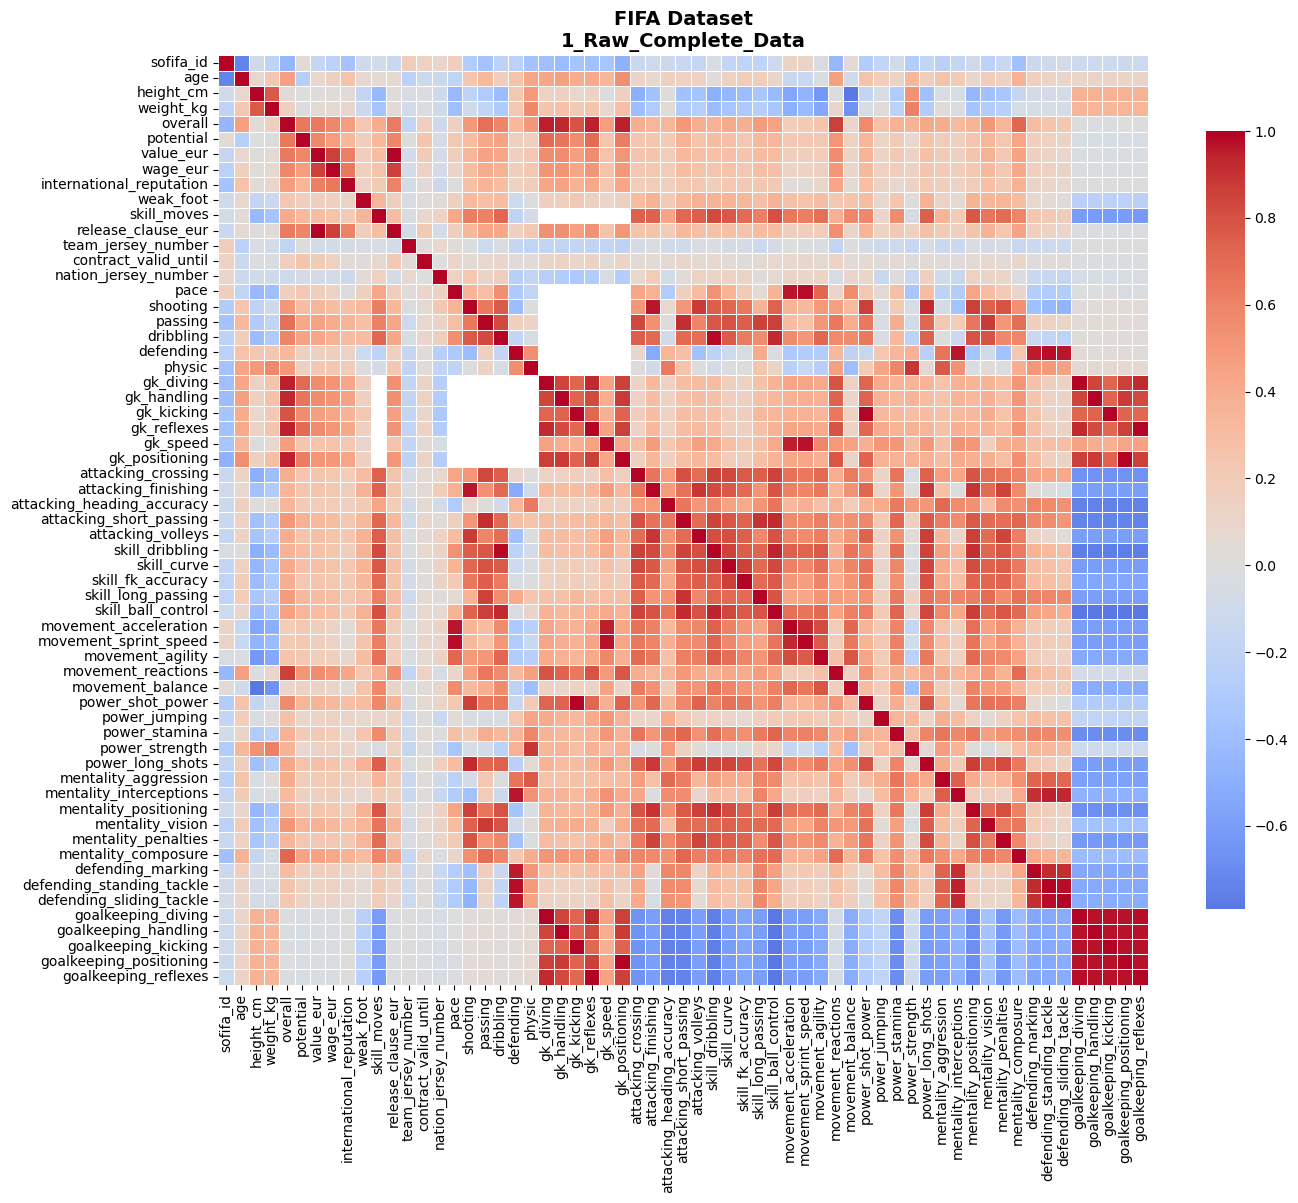


⚠️ HIGH CORRELATIONS > 0.9 at 1_Raw_Complete_Data:
  gk_diving                 ↔ goalkeeping_diving       : 1.0000
  gk_handling               ↔ goalkeeping_handling     : 1.0000
  gk_kicking                ↔ goalkeeping_kicking      : 1.0000
  gk_reflexes               ↔ goalkeeping_reflexes     : 1.0000
  gk_positioning            ↔ goalkeeping_positioning  : 1.0000
  gk_kicking                ↔ power_shot_power         : 0.9988
  value_eur                 ↔ release_clause_eur       : 0.9937
  dribbling                 ↔ skill_dribbling          : 0.9795
  defending_standing_tackle ↔ defending_sliding_tackle : 0.9758
  defending                 ↔ defending_standing_tackle: 0.9756
  pace                      ↔ movement_sprint_speed    : 0.9742
  goalkeeping_diving        ↔ goalkeeping_reflexes     : 0.9739
  goalkeeping_diving        ↔ goalkeeping_handling     : 0.9713
  goalkeeping_handling      ↔ goalkeeping_reflexes     : 0.9712
  goalkeeping_diving        ↔ goalkeeping_positionin

,sofifa_id,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur,international_reputation,weak_foot,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
sofifa_id,1.000000,-0.736680,-0.093464,-0.203620,-0.445061,0.042015,-0.159848,-0.228084,-0.360765,-0.092250,...,-0.147125,-0.385061,-0.131479,-0.087414,-0.068464,-0.113073,-0.116270,-0.114658,-0.123064,-0.113487
age,-0.736680,1.000000,0.081391,0.237169,0.464305,-0.262872,0.081513,0.151031,0.259582,0.073988,...,0.141375,0.370149,0.157007,0.116857,0.101534,0.110313,0.112929,0.112615,0.121381,0.111811
height_cm,-0.093464,0.081391,1.000000,0.768816,0.039945,-0.002432,0.009527,0.019547,0.037935,-0.175200,...,-0.335786,-0.159296,-0.077038,-0.068334,-0.076953,0.367433,0.367163,0.364992,0.367097,0.367375
weight_kg,-0.203620,0.237169,0.768816,1.000000,0.156522,-0.011738,0.051782,0.065946,0.090854,-0.128568,...,-0.246309,-0.054167,-0.049683,-0.052770,-0.064492,0.342329,0.343211,0.339805,0.344397,0.343126
overall,-0.445061,0.464305,0.039945,0.156522,1.000000,0.646650,0.638230,0.573578,0.475557,0.230276,...,0.347950,0.719992,0.303075,0.249891,0.219560,-0.013239,-0.013716,-0.017393,-0.006408,-0.012775
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
goalkeeping_diving,-0.113073,0.110313,0.367433,0.342329,-0.013239,-0.049662,-0.022094,-0.023629,0.006039,-0.232714,...,-0.624495,-0.414361,-0.544390,-0.533440,-0.512461,1.000000,0.971330,0.967057,0.971218,0.973922
goalkeeping_handling,-0.116270,0.112929,0.367163,0.343211,-0.013716,-0.050859,-0.022119,-0.023590,0.005962,-0.232357,...,-0.623164,-0.413082,-0.545373,-0.534141,-0.513340,0.971330,1.000000,0.966508,0.970517,0.971244
goalkeeping_kicking,-0.114658,0.112615,0.364992,0.339805,-0.017393,-0.056216,-0.023048,-0.024679,0.004454,-0.228380,...,-0.619899,-0.411327,-0.542991,-0.533623,-0.512314,0.967057,0.966508,1.000000,0.966061,0.967866
goalkeeping_positioning,-0.123064,0.121381,0.367097,0.344397,-0.006408,-0.049007,-0.020554,-0.022428,0.008561,-0.230529,...,-0.621893,-0.406664,-0.540967,-0.530873,-0.509761,0.971218,0.970517,0.966061,1.000000,0.971060


In [51]:
print("\n" + "="*60)
print("STAGE 1: Correlation Heatmap - Raw Data (Before ANY processing)")
print("="*60)
plot_correlation_heatmap(df, "FIFA Dataset", "1_Raw_Complete_Data", triangle=False)

## Drop unecessary columns

In [17]:

pos_cols = ['ls', 'st', 'rs', 'lw', 'lf', 'cf', 'rf', 'rw', 'lam', 'cam', 'ram', 
            'lm', 'lcm', 'cm', 'rcm', 'rm', 'lwb', 'ldm', 'cdm', 'rdm', 'rwb', 
            'lb', 'lcb', 'cb', 'rcb', 'rb']


for col in pos_cols:
    df[col] = df[col].apply(parse_position_rating)

df['max_position_rating'] = df[pos_cols].max(axis=1)
df['avg_position_rating'] = df[pos_cols].mean(axis=1)
df['num_positions'] = (df[pos_cols] > 0).sum(axis=1)

df = df.drop(columns=pos_cols + ['sofifa_id', 'player_url', 'short_name', 'long_name', 'dob'])

print(f"✅ Position ratings aggregated: {len(pos_cols)} columns → 3 features")

✅ Position ratings aggregated: 26 columns → 3 features


In [18]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [19]:
train_df.describe()

,age,height_cm,weight_kg,overall,potential,wage_eur,international_reputation,weak_foot,skill_moves,team_jersey_number,...,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,reputation_binary,overall_3class,max_position_rating,avg_position_rating,num_positions
count,14622.000000,14622.000000,14622.000000,14622.000000,14622.000000,14622.000000,14622.000000,14622.000000,14622.000000,14437.000000,...,14622.000000,14622.000000,14622.000000,14622.000000,14622.000000,14622.000000,14622.000000,14622.000000,14622.000000,14622.000000
mean,25.296950,181.404185,75.323690,66.244631,71.547394,9453.973465,1.104637,2.948297,2.366092,20.083466,...,16.573451,16.342566,16.193339,16.360621,16.705239,0.082615,0.975106,59.923335,53.197069,23.103406
std,4.665771,6.740255,7.041141,6.968874,6.137319,21096.646630,0.379877,0.660207,0.765480,16.640021,...,17.708869,16.957200,16.598833,17.106272,18.006526,0.275309,0.803987,22.179690,20.141750,8.180817
min,16.000000,156.000000,50.000000,48.000000,49.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,177.000000,70.000000,62.000000,67.000000,1000.000000,1.000000,3.000000,2.000000,8.000000,...,8.000000,8.000000,8.000000,8.000000,8.000000,0.000000,0.000000,61.000000,52.076923,26.000000
50%,25.000000,181.000000,75.000000,66.000000,71.000000,3000.000000,1.000000,3.000000,2.000000,17.000000,...,11.000000,11.000000,11.000000,11.000000,11.000000,0.000000,1.000000,66.000000,58.692308,26.000000
75%,29.000000,186.000000,80.000000,71.000000,75.000000,8000.000000,1.000000,3.000000,3.000000,27.000000,...,14.000000,14.000000,14.000000,14.000000,14.000000,0.000000,2.000000,71.000000,64.269231,26.000000
max,42.000000,205.000000,110.000000,93.000000,95.000000,470000.000000,5.000000,5.000000,5.000000,99.000000,...,90.000000,89.000000,93.000000,90.000000,92.000000,1.000000,2.000000,94.000000,84.192308,26.000000


In [20]:
import hashlib

# Visualition of targets

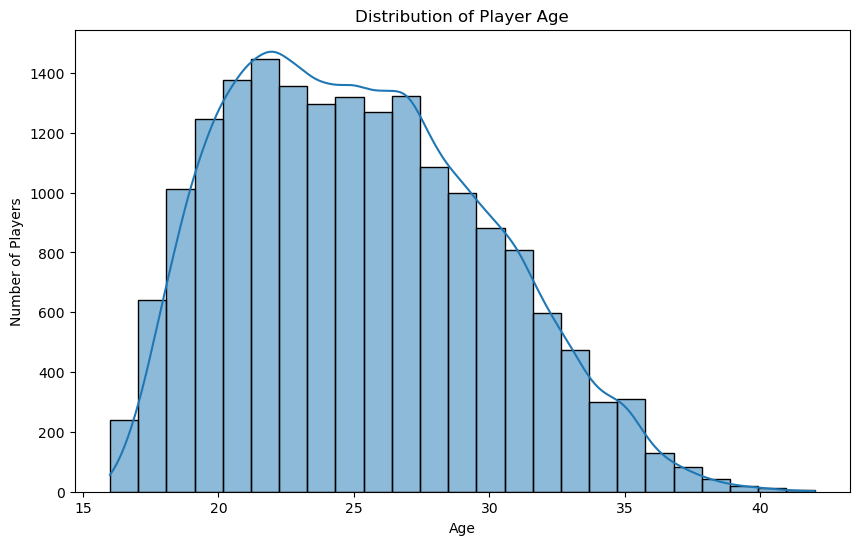

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(df["age"], bins=25, kde=True)
plt.title("Distribution of Player Age")
plt.xlabel("Age")
plt.ylabel("Number of Players")
plt.show()

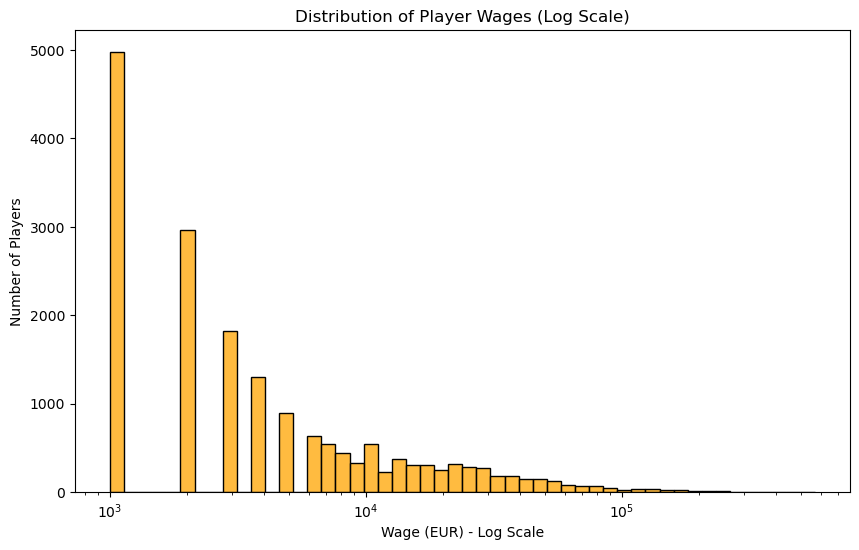

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(df["wage_eur"], bins=50, color="orange", log_scale=True)
plt.title("Distribution of Player Wages (Log Scale)")
plt.xlabel("Wage (EUR) - Log Scale")
plt.ylabel("Number of Players")
plt.show()

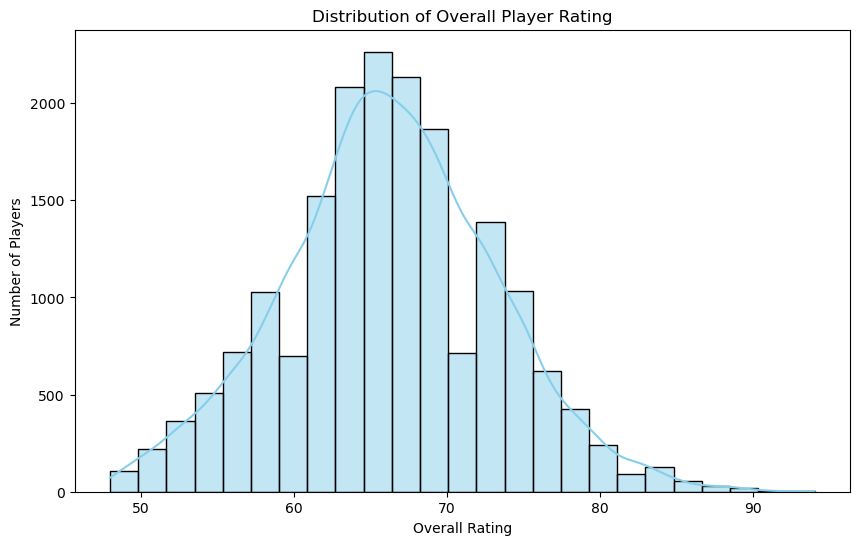

In [46]:
plt.figure(figsize=(10, 6))
sns.histplot(df["overall"], bins=25, kde=True, color="skyblue")
plt.title("Distribution of Overall Player Rating")
plt.xlabel("Overall Rating")
plt.ylabel("Number of Players")
plt.show()

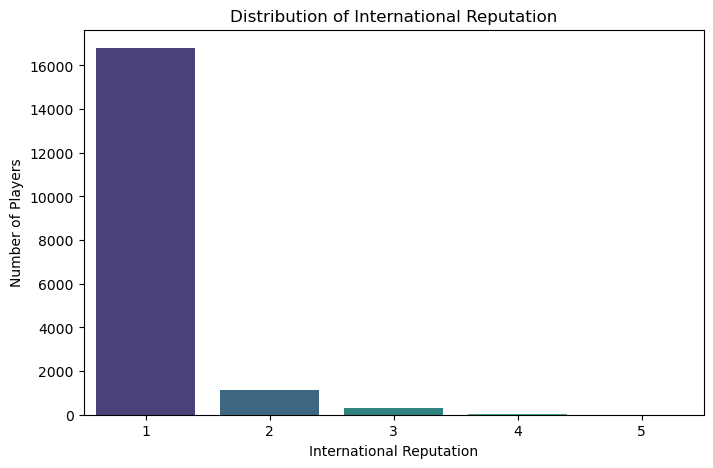

In [23]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df["international_reputation"], palette="viridis")
plt.title("Distribution of International Reputation")
plt.xlabel("International Reputation")
plt.ylabel("Number of Players")
plt.show()

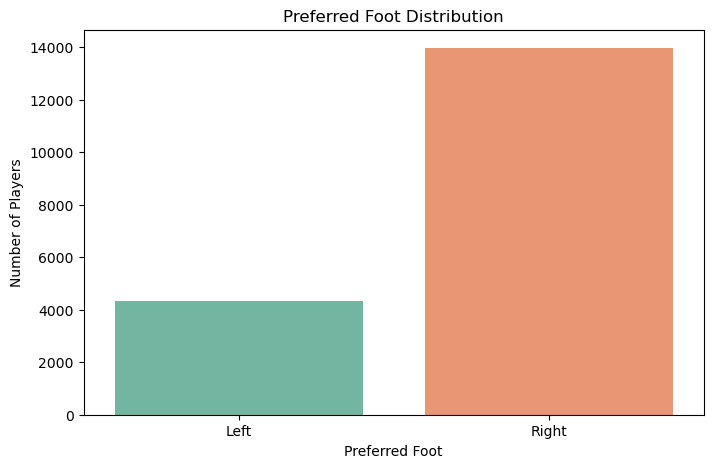

In [24]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df["preferred_foot"], palette="Set2")
plt.title("Preferred Foot Distribution")
plt.xlabel("Preferred Foot")
plt.ylabel("Number of Players")
plt.show()

# Anova Testing

In [25]:

from scipy import stats

print("--- One-Way ANOVA Results ---")

# 1. Does International Reputation impact Overall Rating?

rep_groups = [df[df['international_reputation'] == level]['overall'] 
              for level in sorted(df['international_reputation'].unique())]

f_stat_rep, p_val_rep = stats.f_oneway(*rep_groups)

print(f"ANOVA (International Reputation vs Overall):")
print(f"  - F-statistic: {f_stat_rep:.2f}")
print(f"  - p-value: {p_val_rep:.6e}")

if p_val_rep < 0.05:
    print("  - Result: Statistically Significant (Reputation affects Overall)")
else:
    print("  - Result: Not Significant")

print("-" * 30)

# 2. Does Preferred Foot impact Overall Rating?
foot_groups = [df[df['preferred_foot'] == foot]['overall'] 
               for foot in df['preferred_foot'].dropna().unique()]

f_stat_foot, p_val_foot = stats.f_oneway(*foot_groups)

print(f"ANOVA (Preferred Foot vs Overall):")
print(f"  - F-statistic: {f_stat_foot:.2f}")
print(f"  - p-value: {p_val_foot:.6e}")

if p_val_foot < 0.05:
    print("  - Result: Statistically Significant (Foot choice affects Overall)")
else:
    print("  - Result: Not Significant (Minimal to no impact)")

--- One-Way ANOVA Results ---
ANOVA (International Reputation vs Overall):
  - F-statistic: 1393.12
  - p-value: 0.000000e+00
  - Result: Statistically Significant (Reputation affects Overall)
------------------------------
ANOVA (Preferred Foot vs Overall):
  - F-statistic: 21.75
  - p-value: 3.135197e-06
  - Result: Statistically Significant (Foot choice affects Overall)


# Identify missing values in traing and testing

In [26]:
show_missing_values(train_df)


--- Current Missing Values ---
player_tags             13422
team_position             185
team_jersey_number        185
loaned_from             13772
joined                   1035
contract_valid_until      185
nation_position         13738
nation_jersey_number    13738
pace                     1629
shooting                 1629
passing                  1629
dribbling                1629
defending                1629
physic                   1629
gk_diving               12993
gk_handling             12993
gk_kicking              12993
gk_reflexes             12993
gk_speed                12993
gk_positioning          12993
player_traits            8556
dtype: int64


In [27]:
show_missing_values(test_df)


--- Current Missing Values ---
player_tags             3357
team_position             55
team_jersey_number        55
loaned_from             3458
joined                   253
contract_valid_until      55
nation_position         3414
nation_jersey_number    3414
pace                     407
shooting                 407
passing                  407
dribbling                407
defending                407
physic                   407
gk_diving               3249
gk_handling             3249
gk_kicking              3249
gk_reflexes             3249
gk_speed                3249
gk_positioning          3249
player_traits           2156
dtype: int64


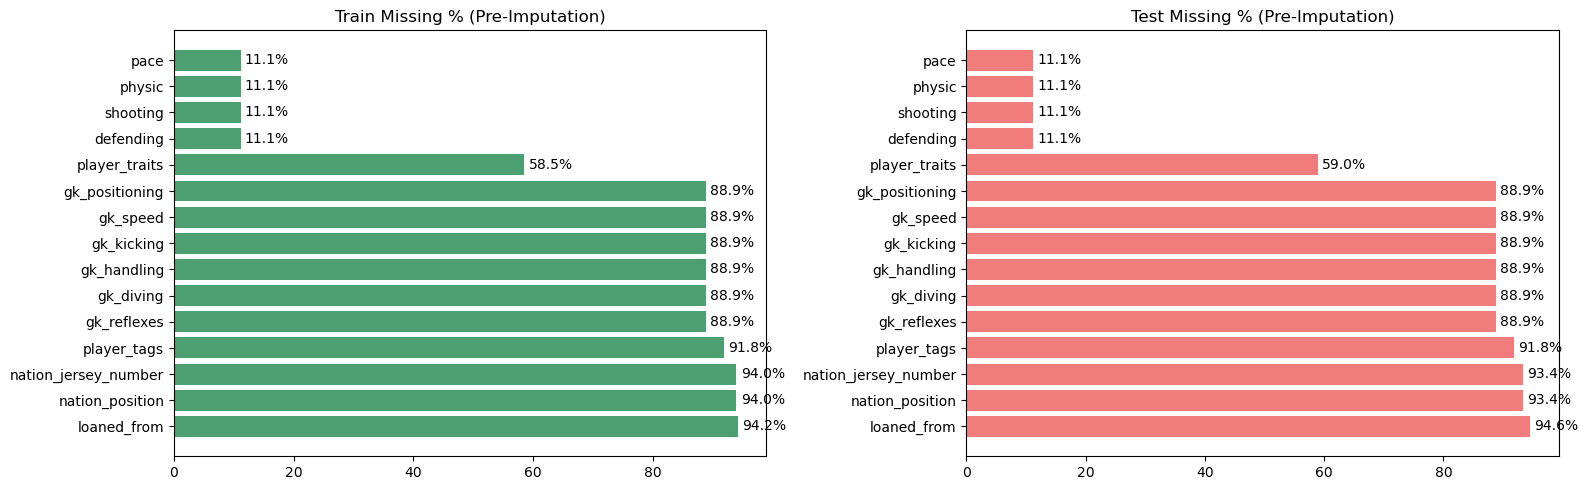

In [28]:
plot_missing_percentage_dual(train_df, test_df, stage="Pre-Imputation")

# Imputations

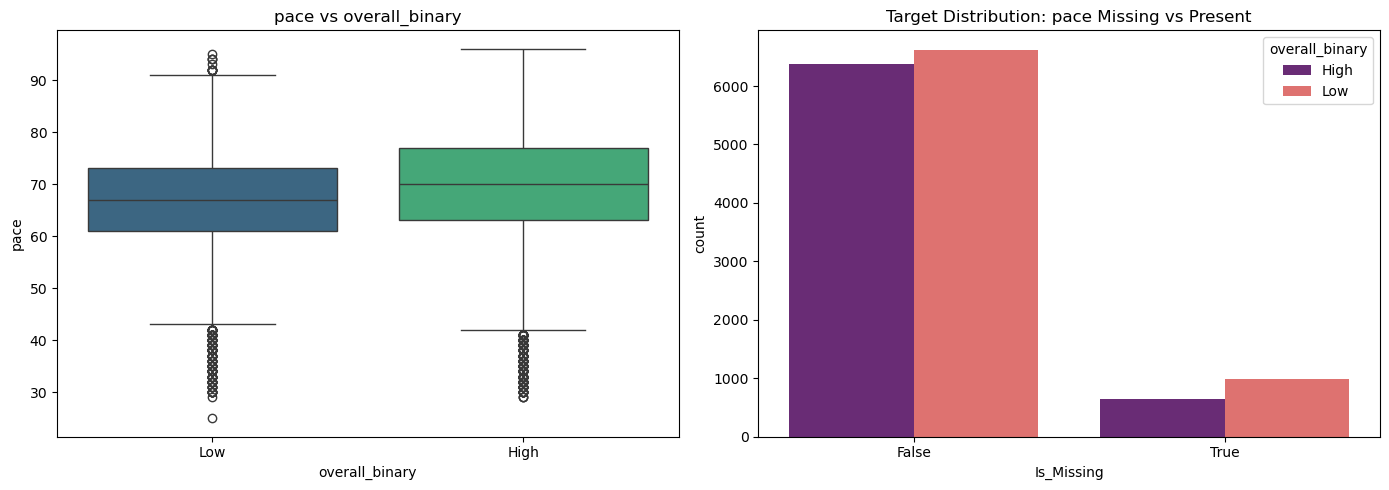

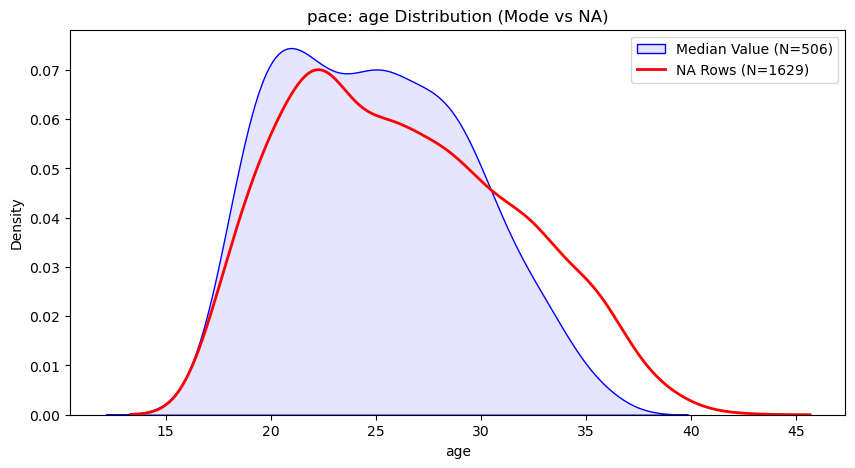

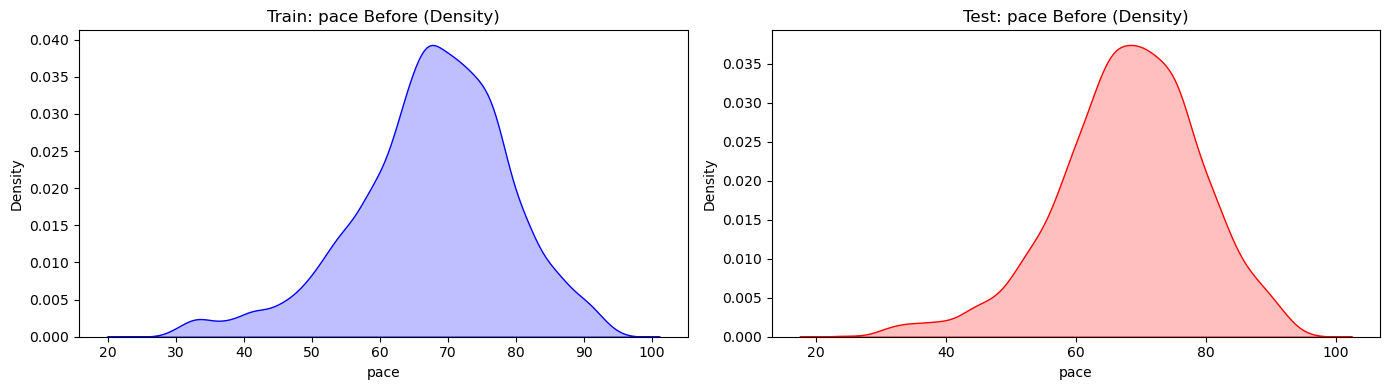

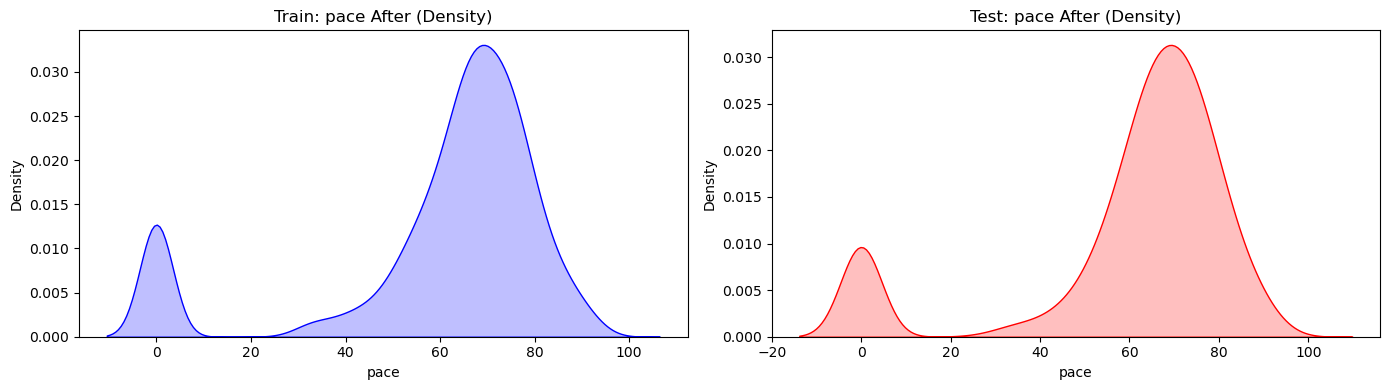

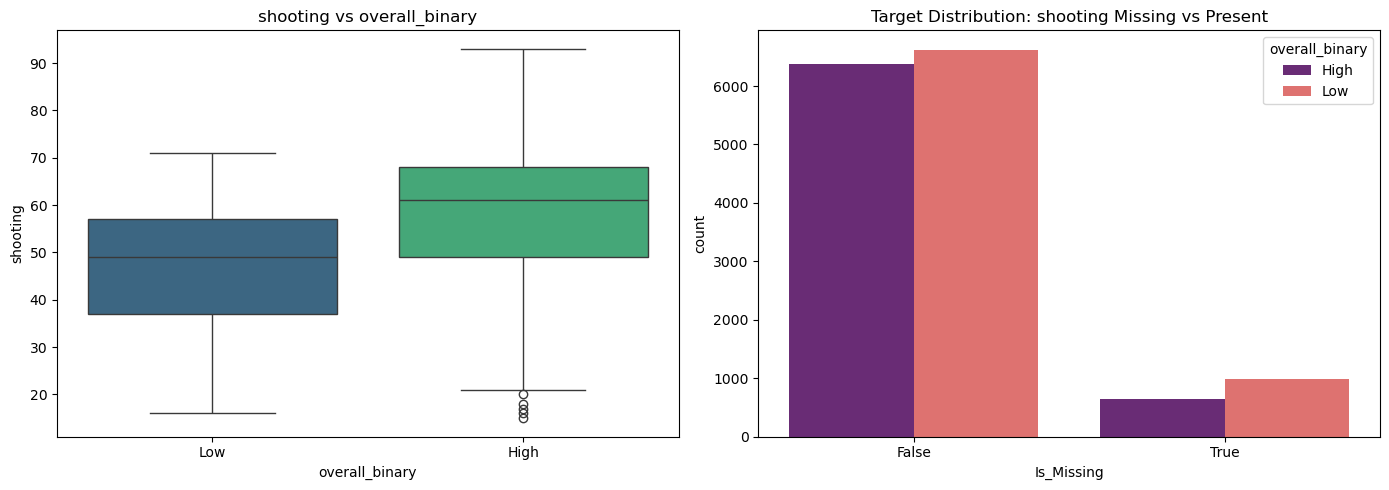

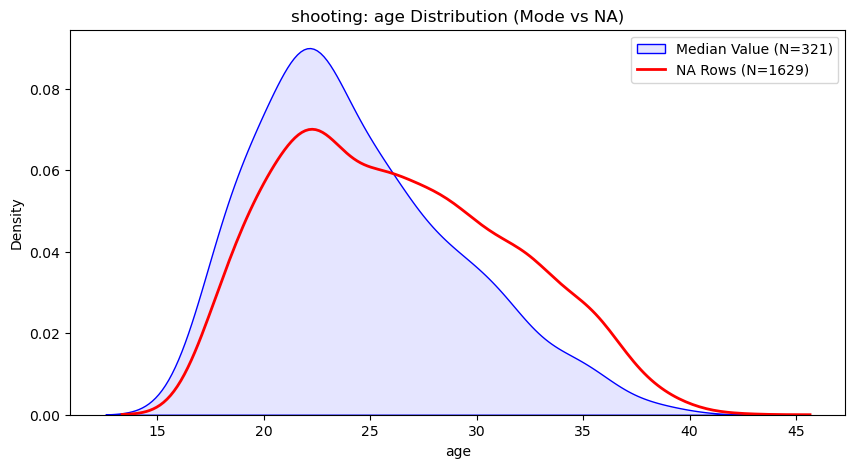

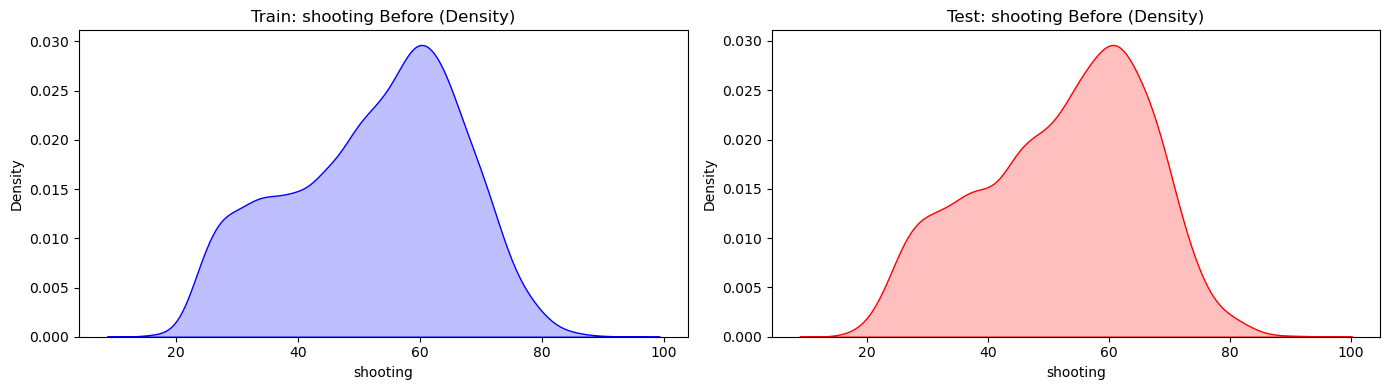

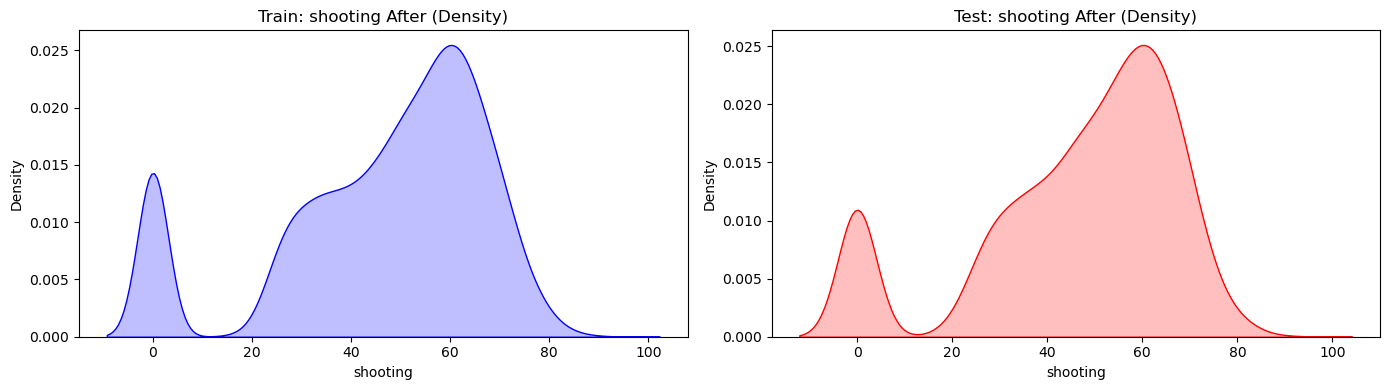

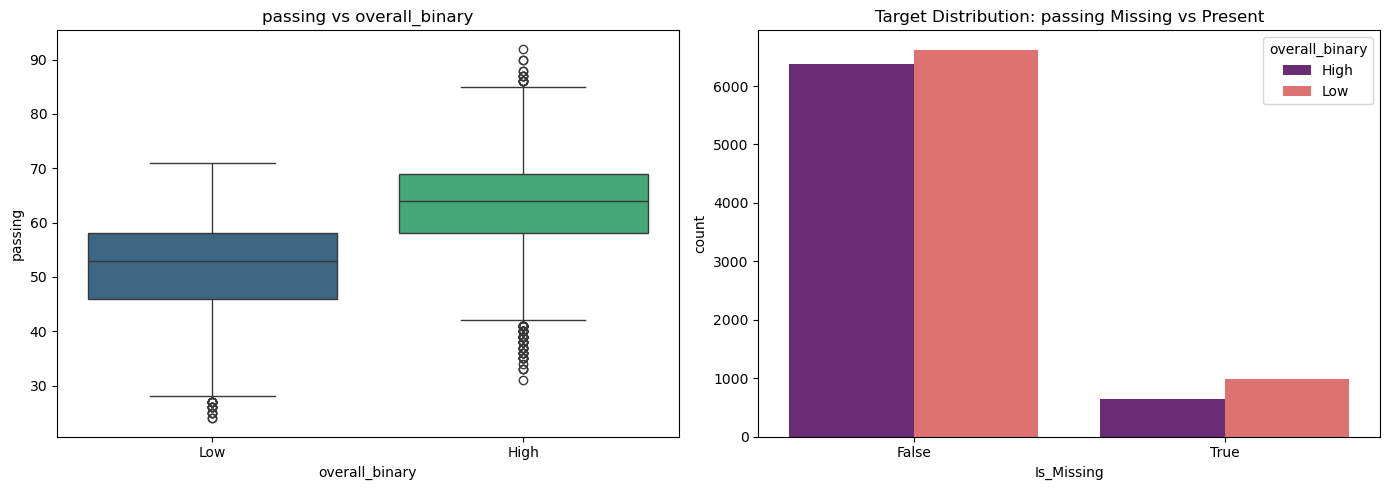

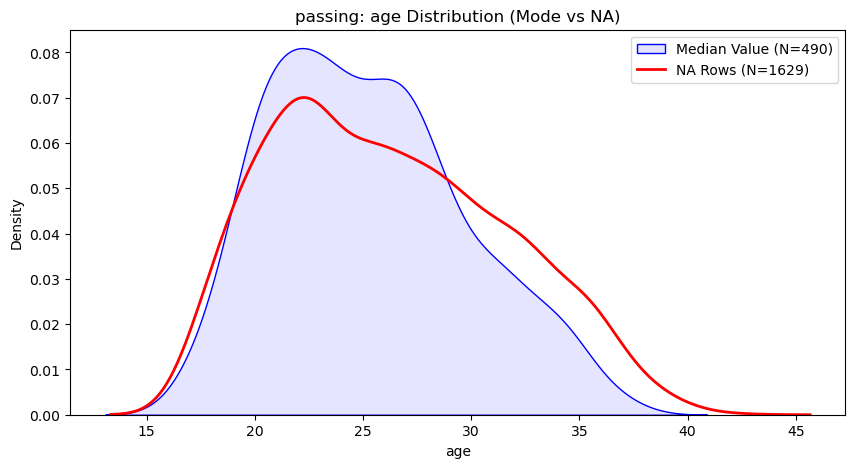

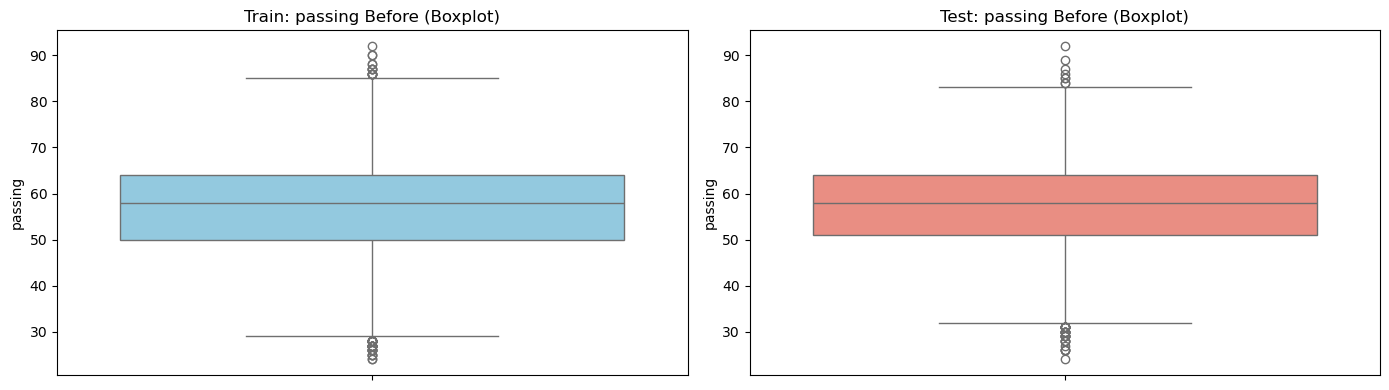

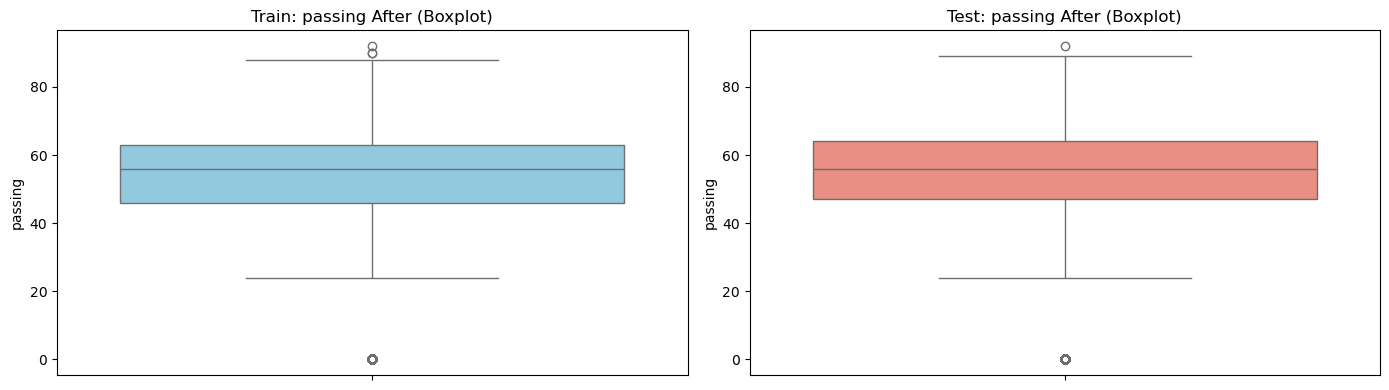

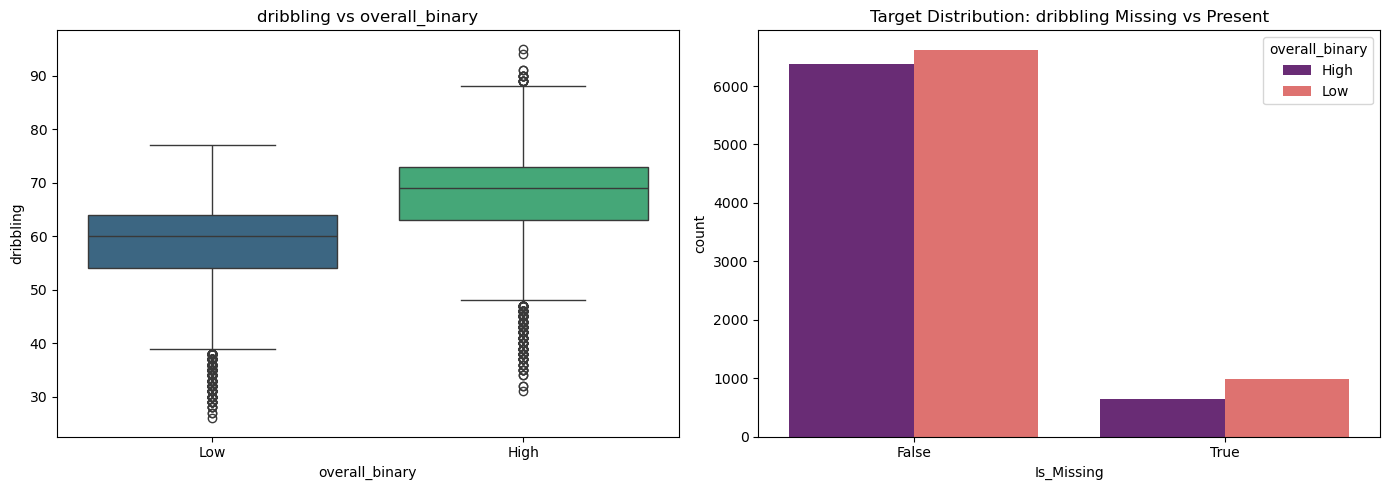

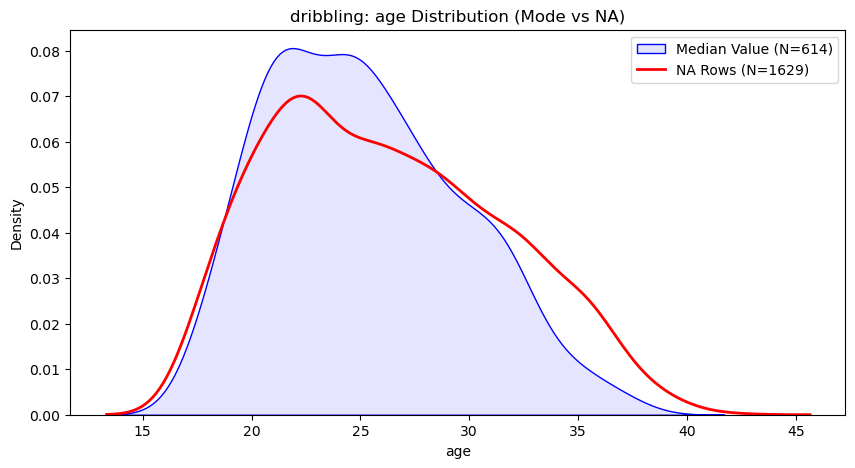

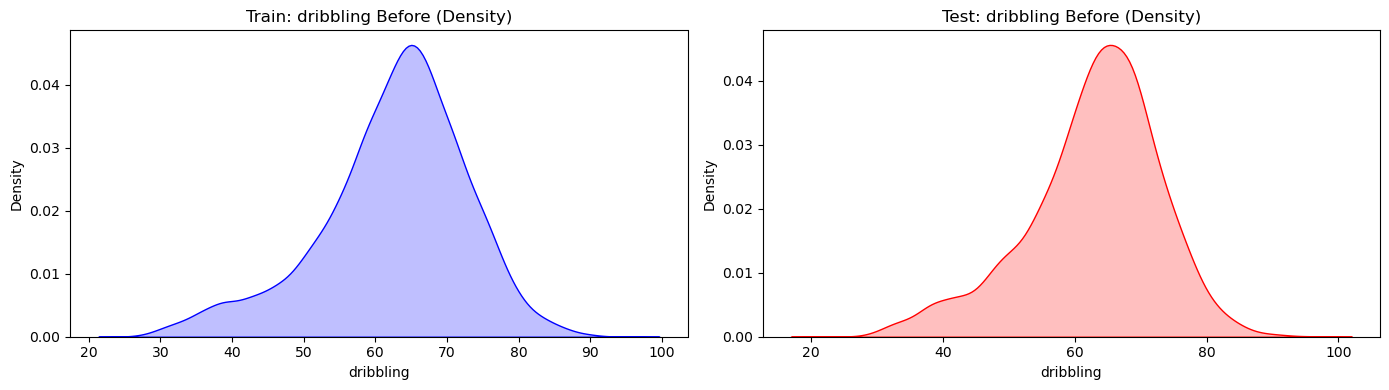

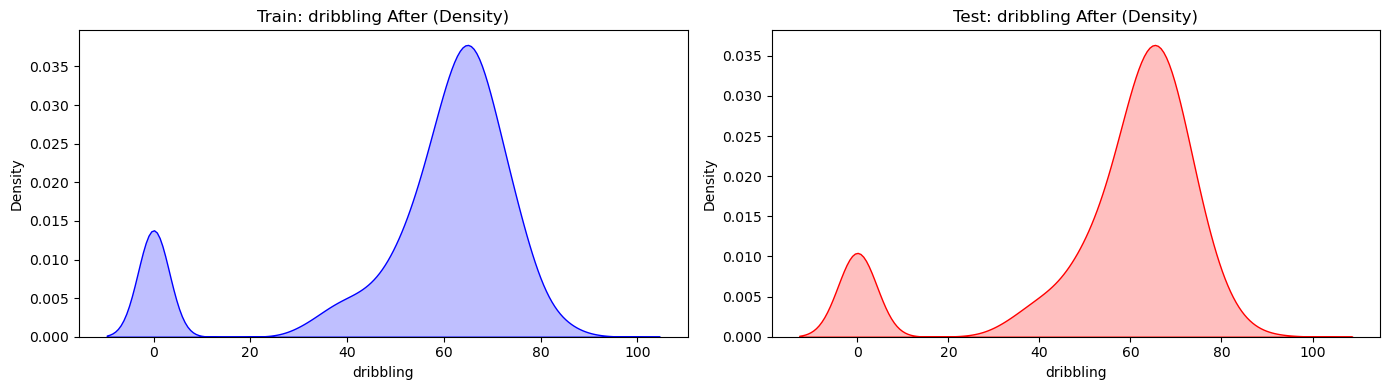

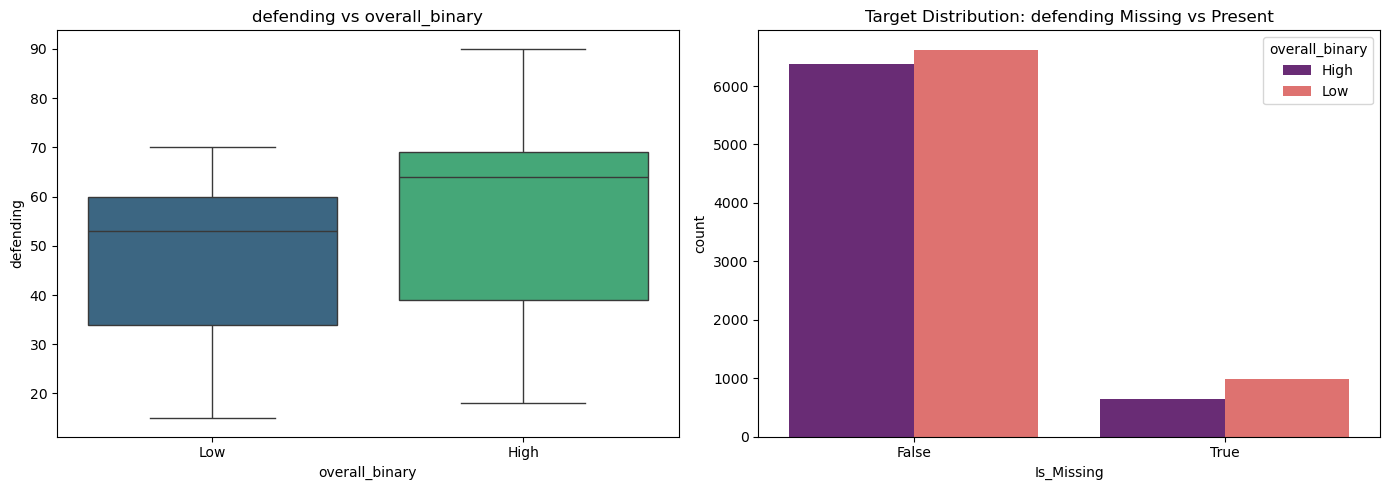

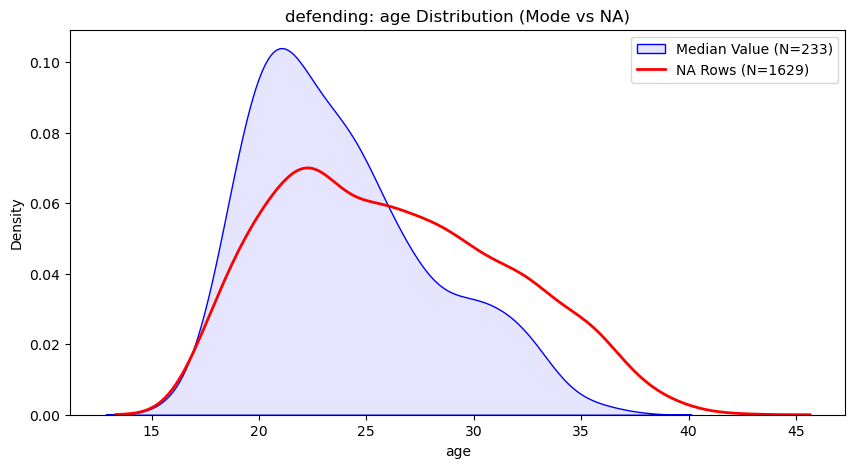

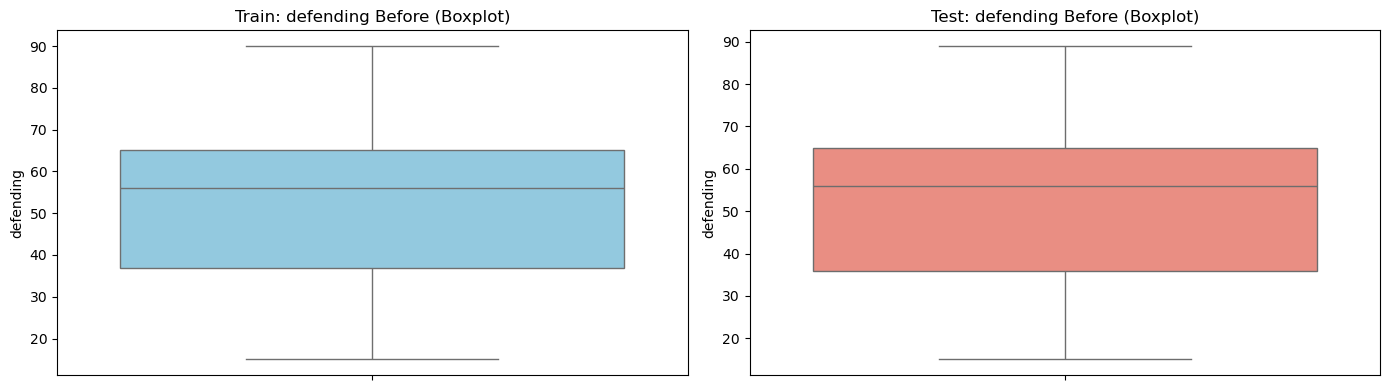

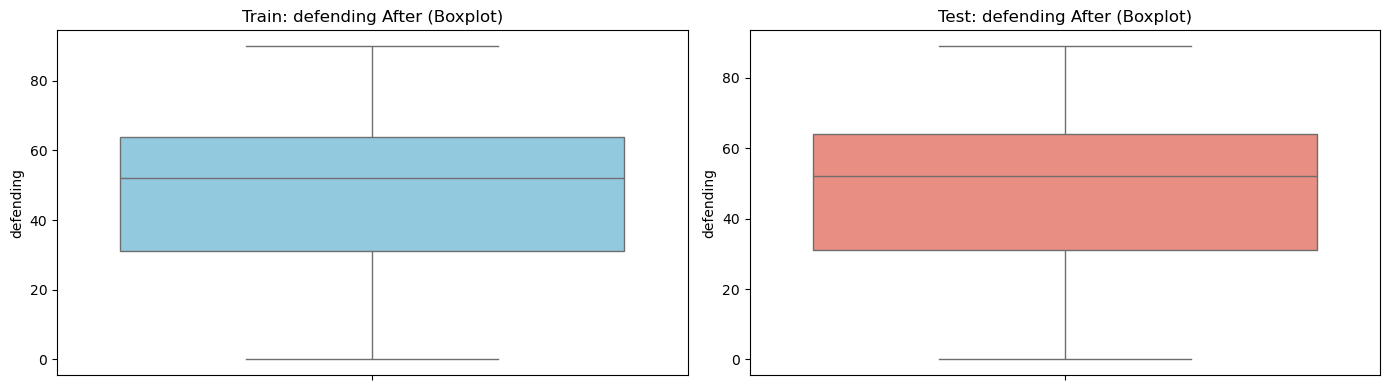

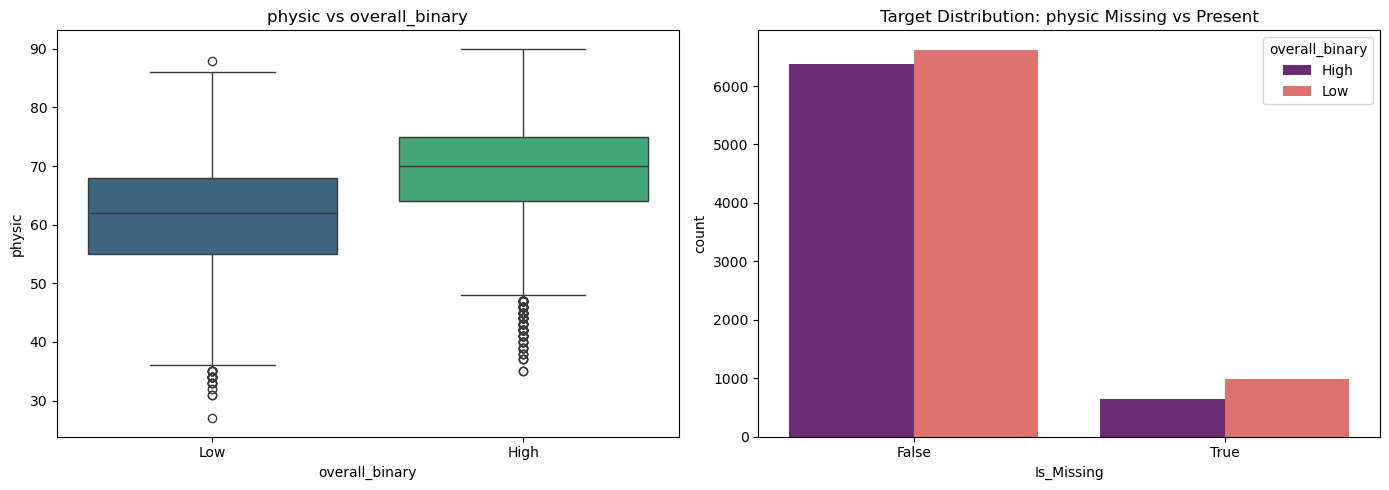

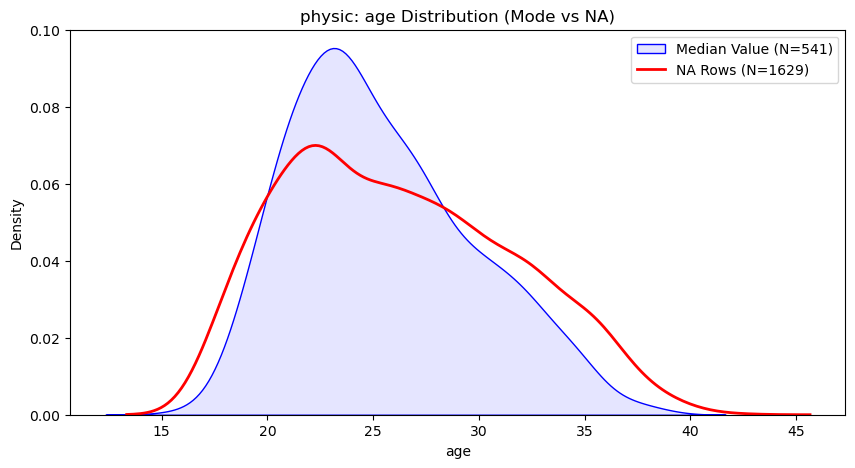

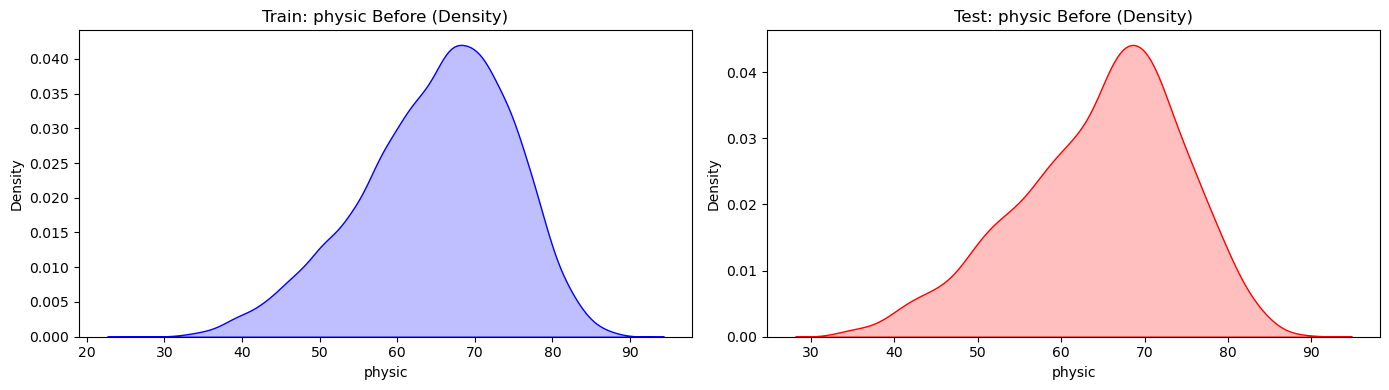

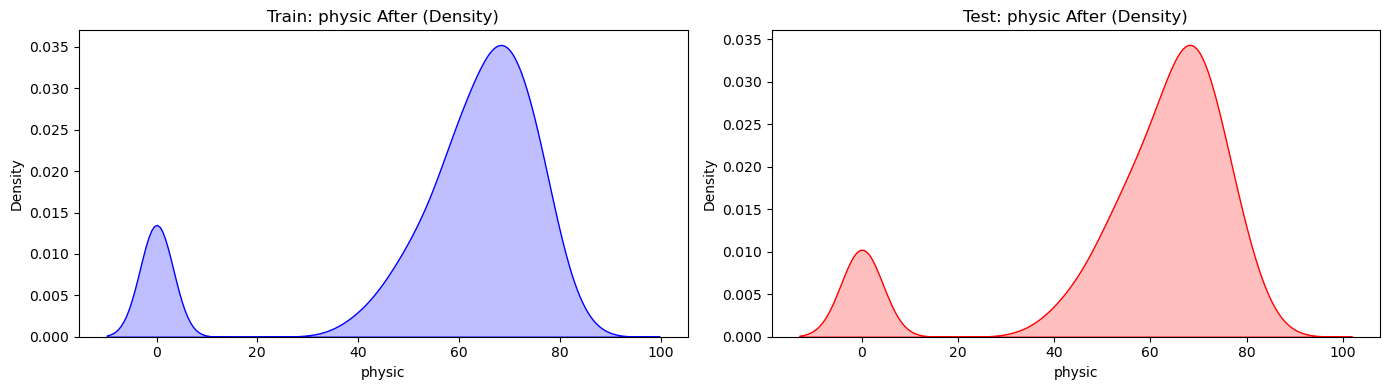

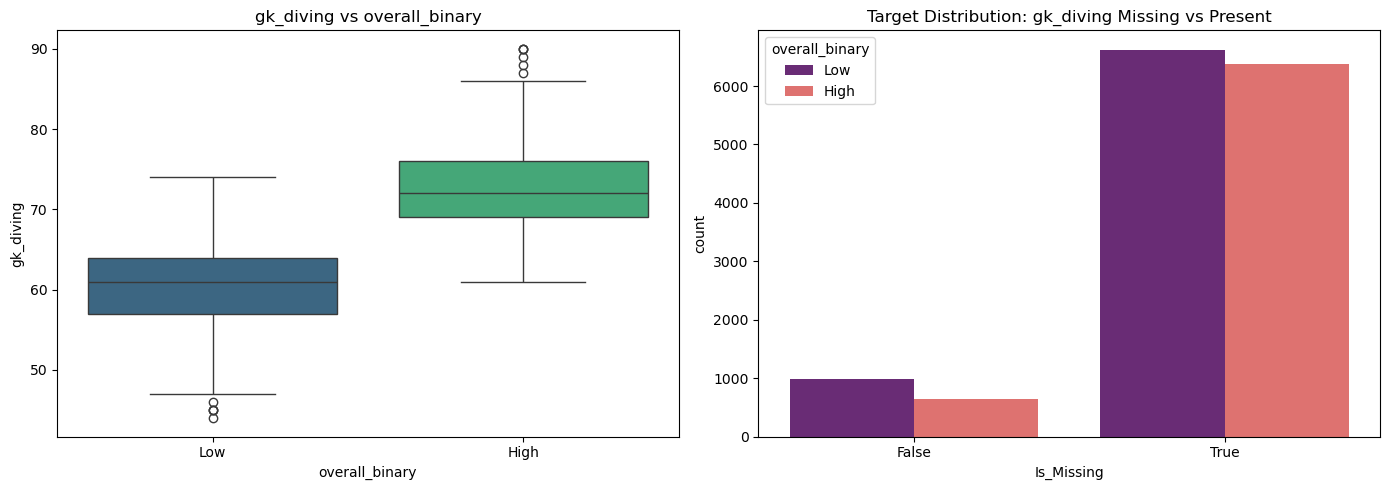

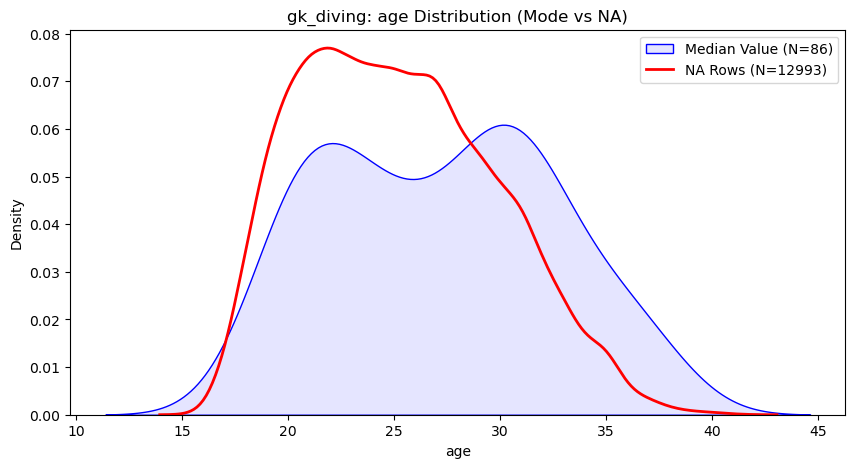

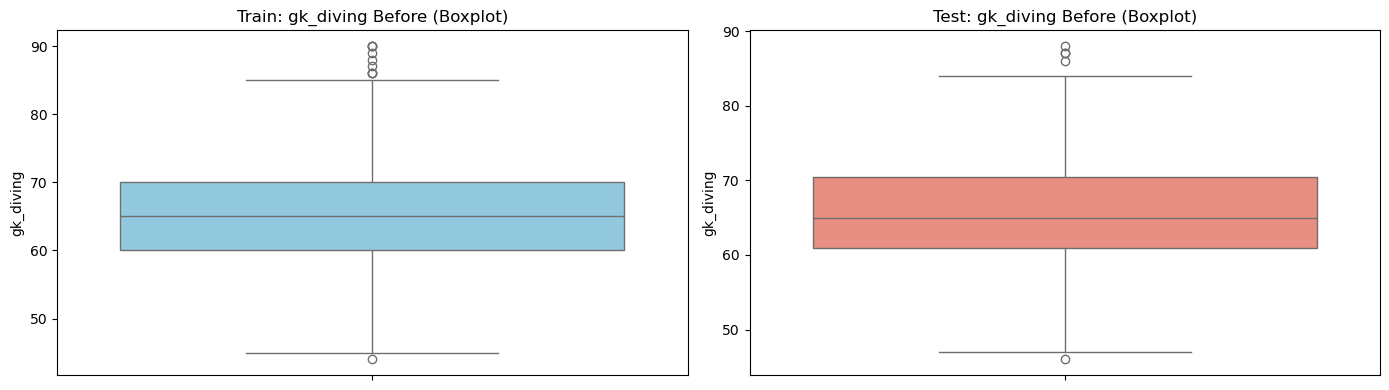

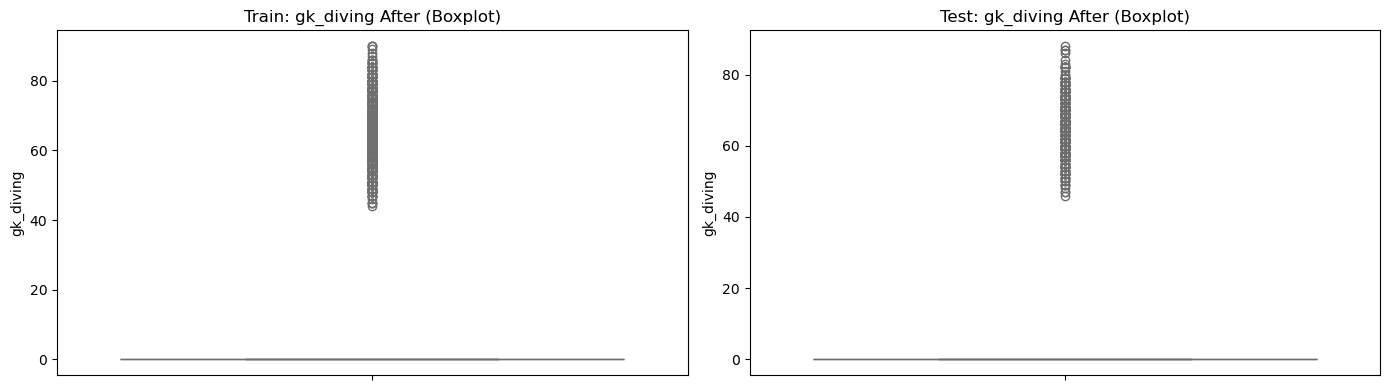

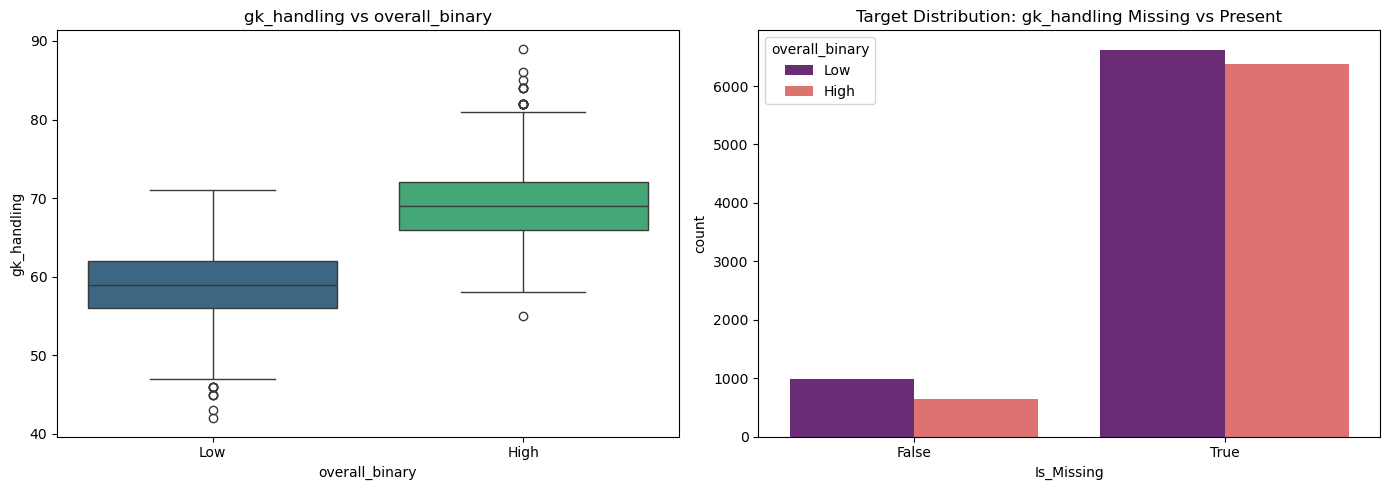

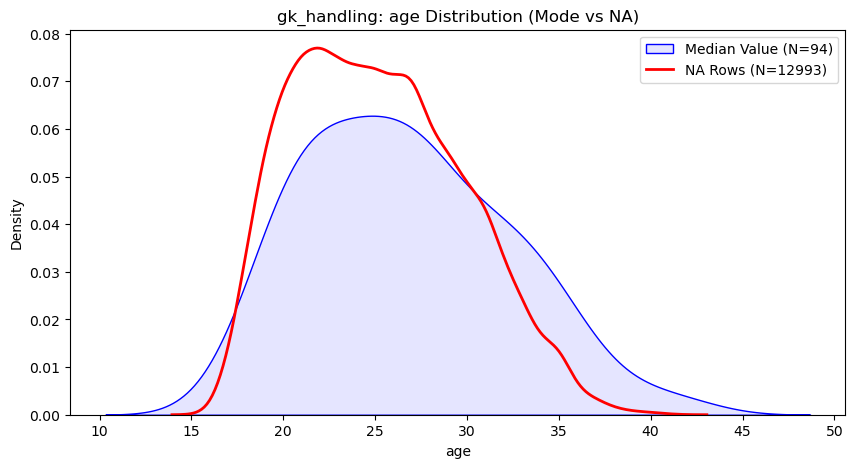

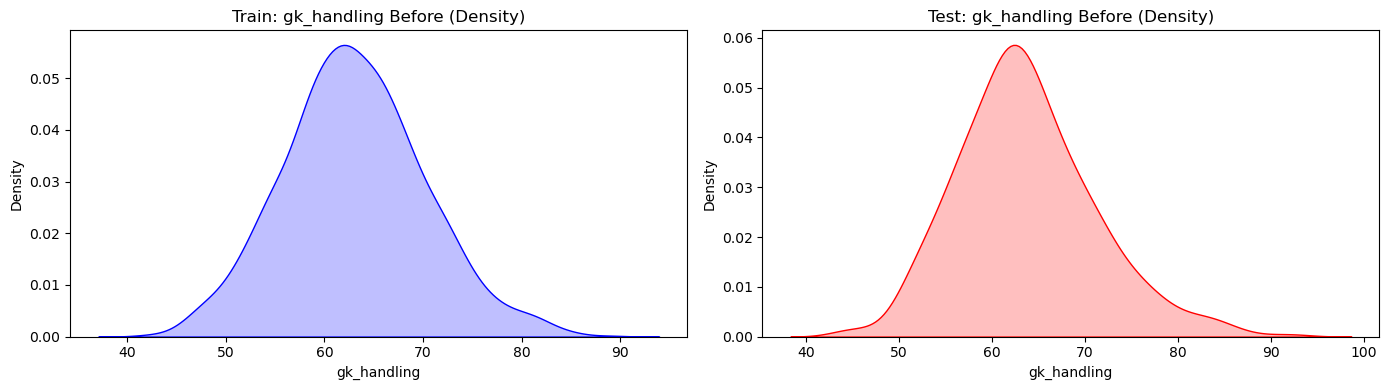

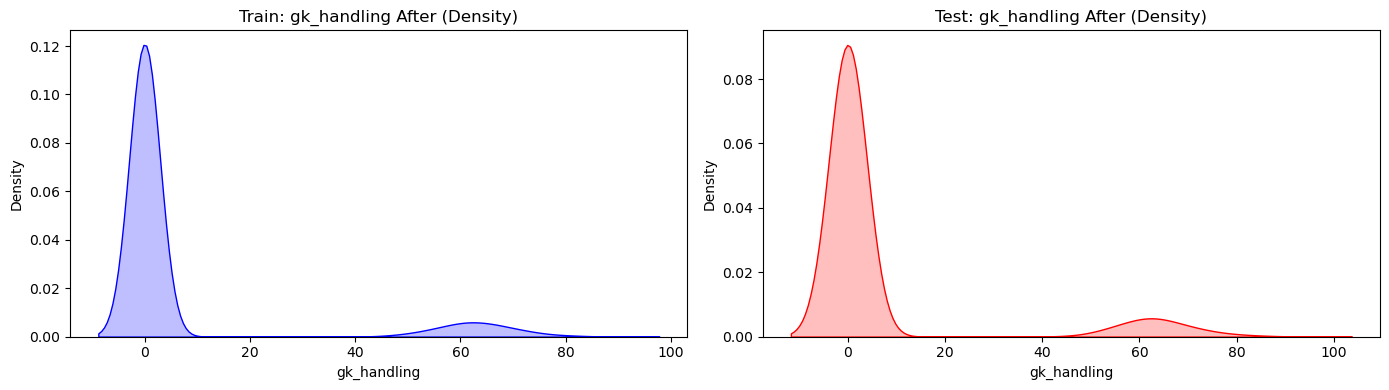

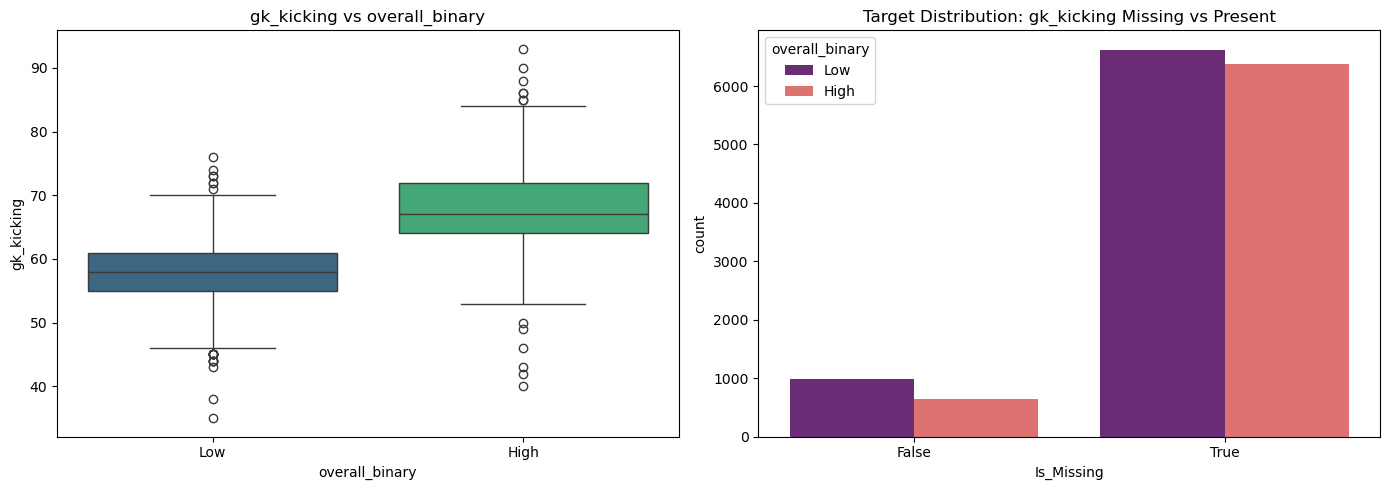

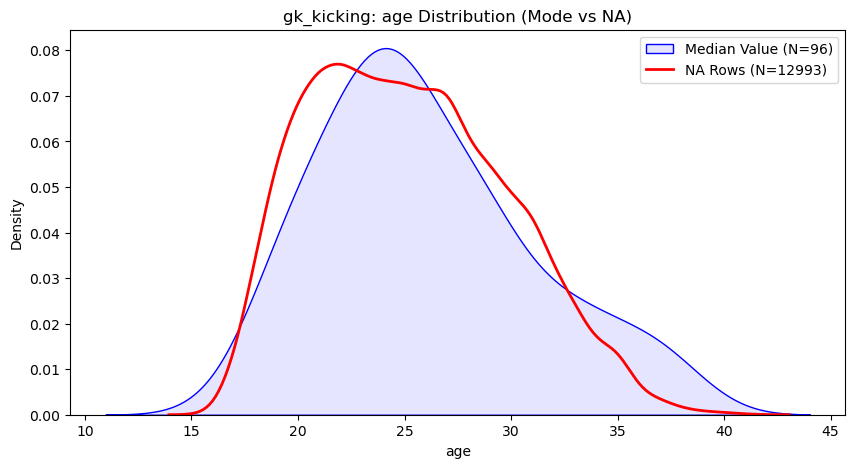

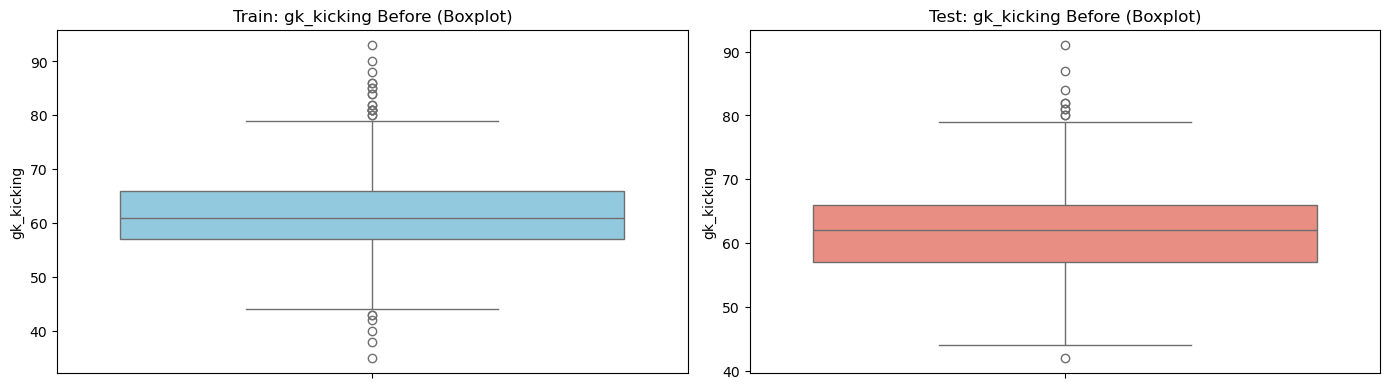

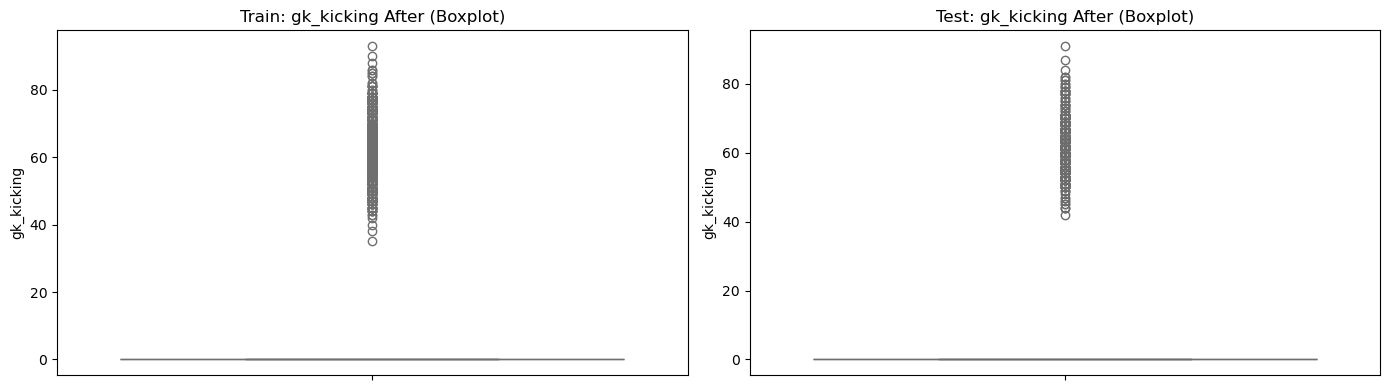

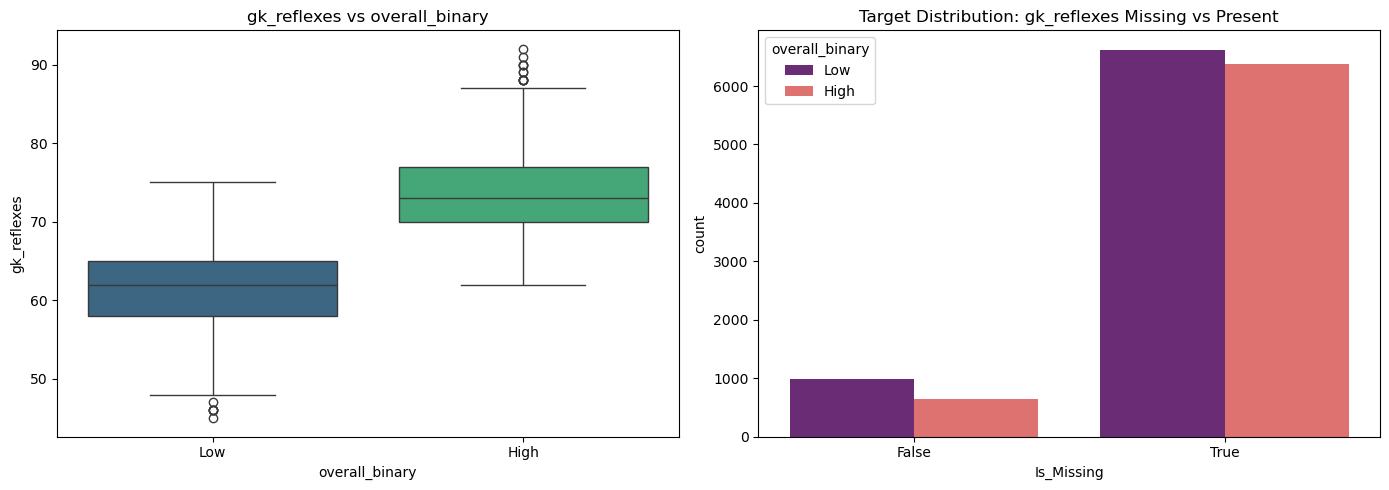

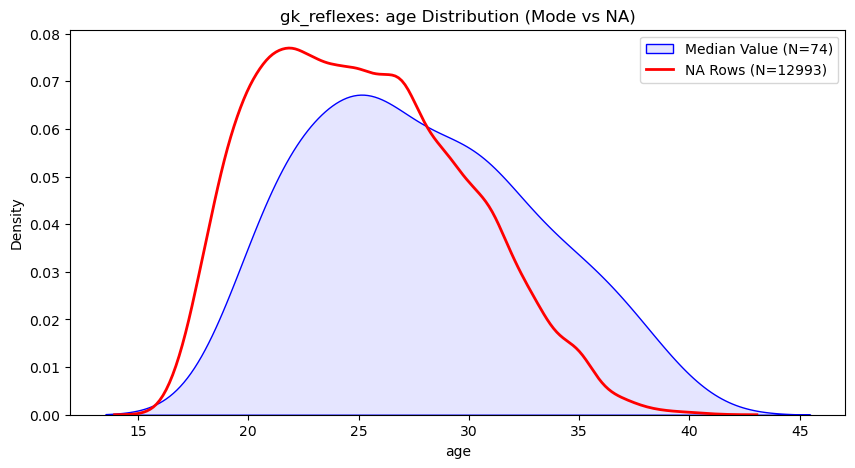

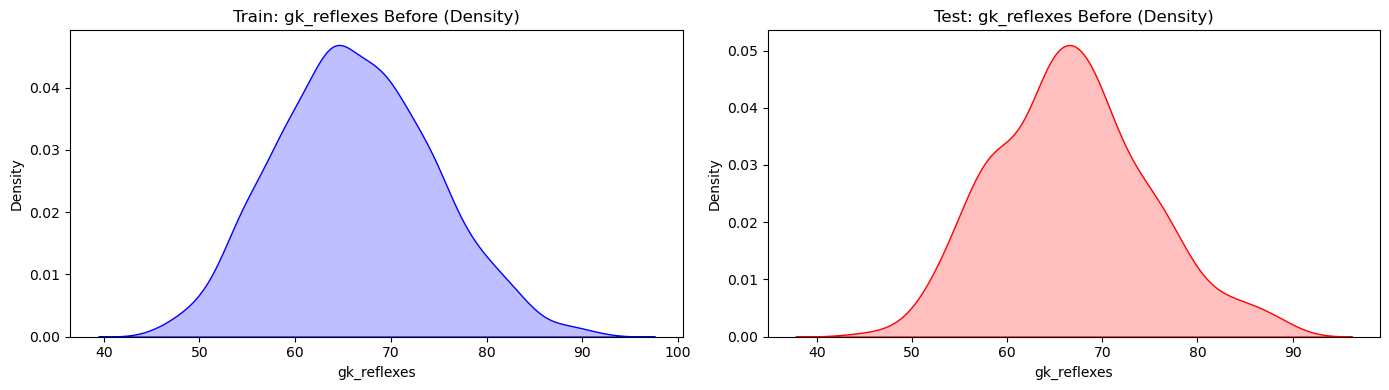

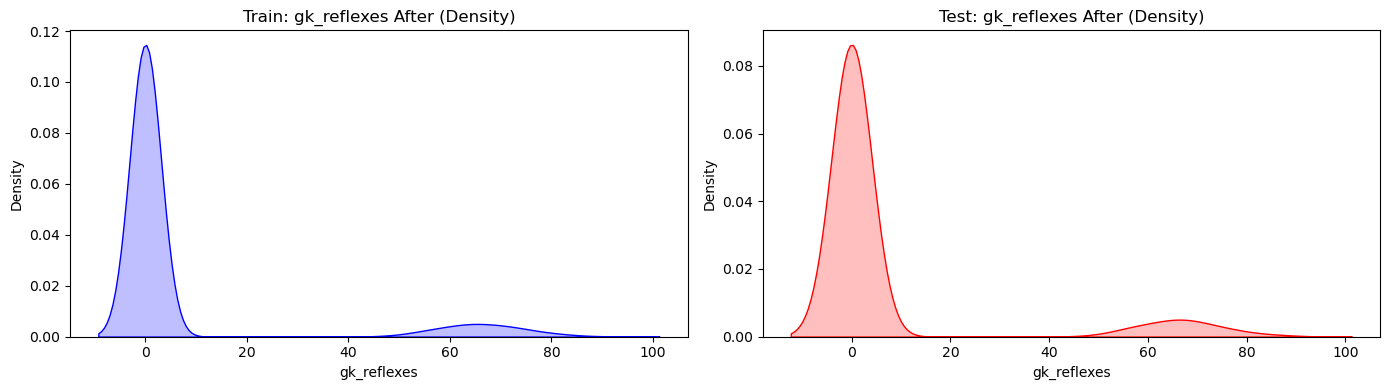

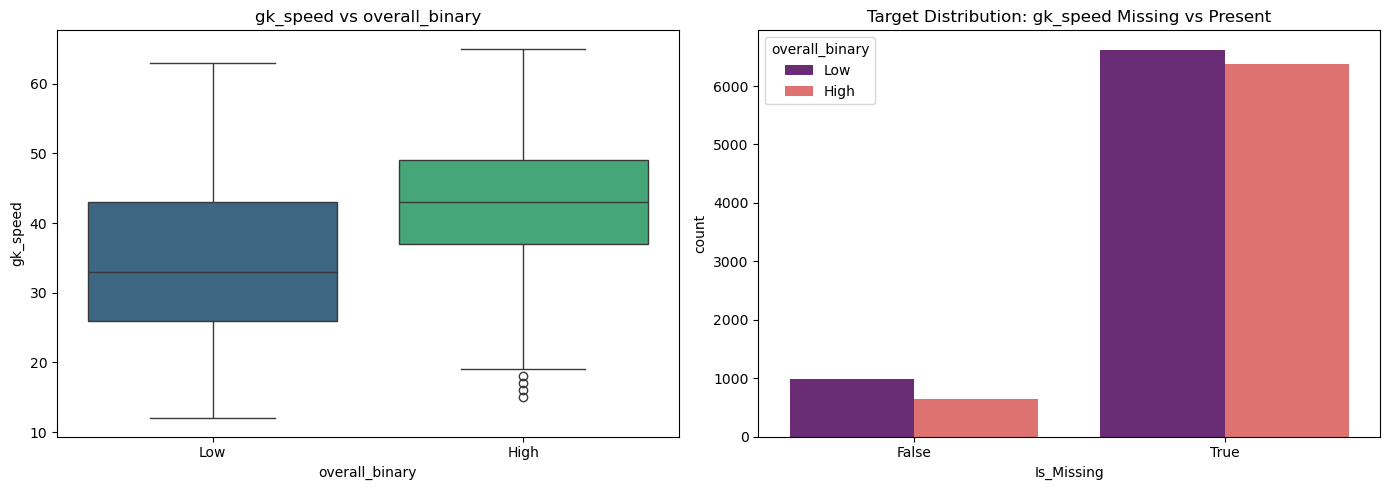

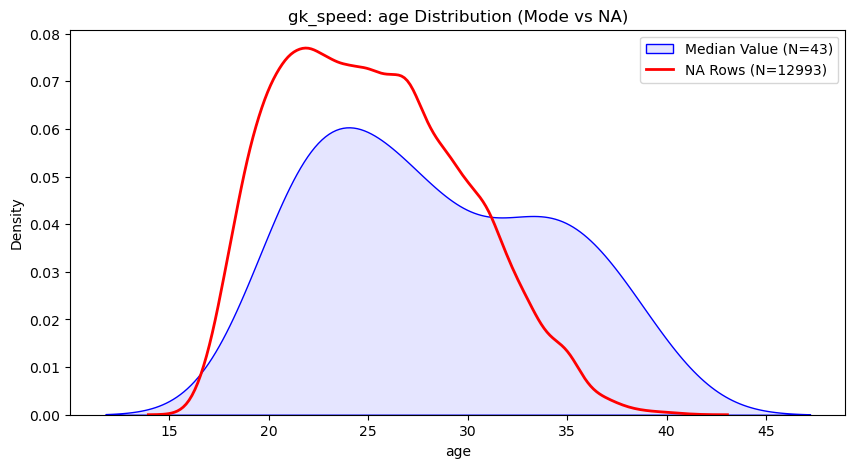

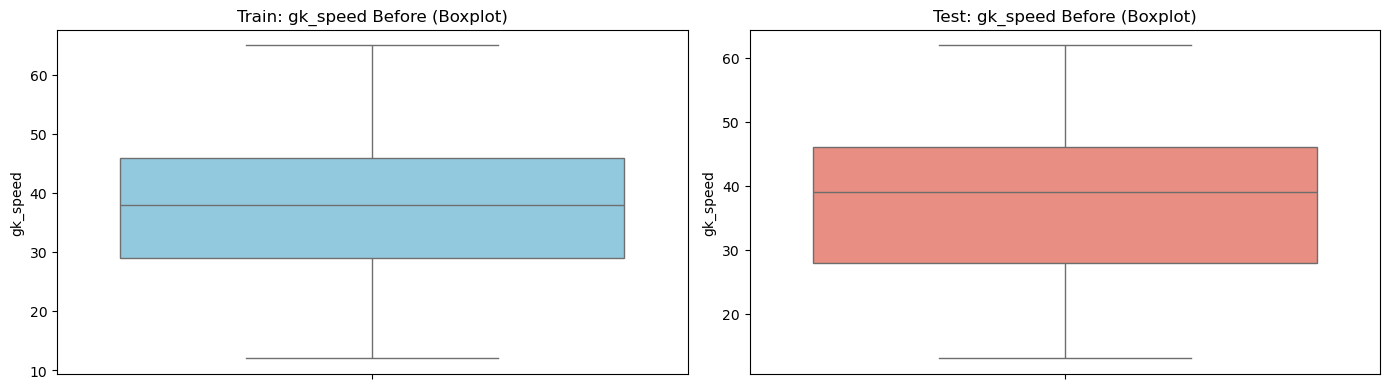

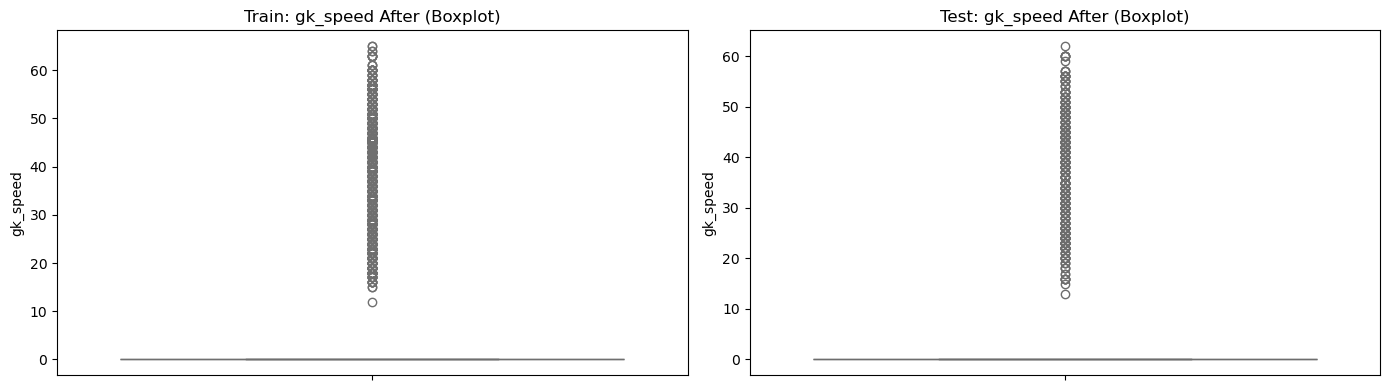

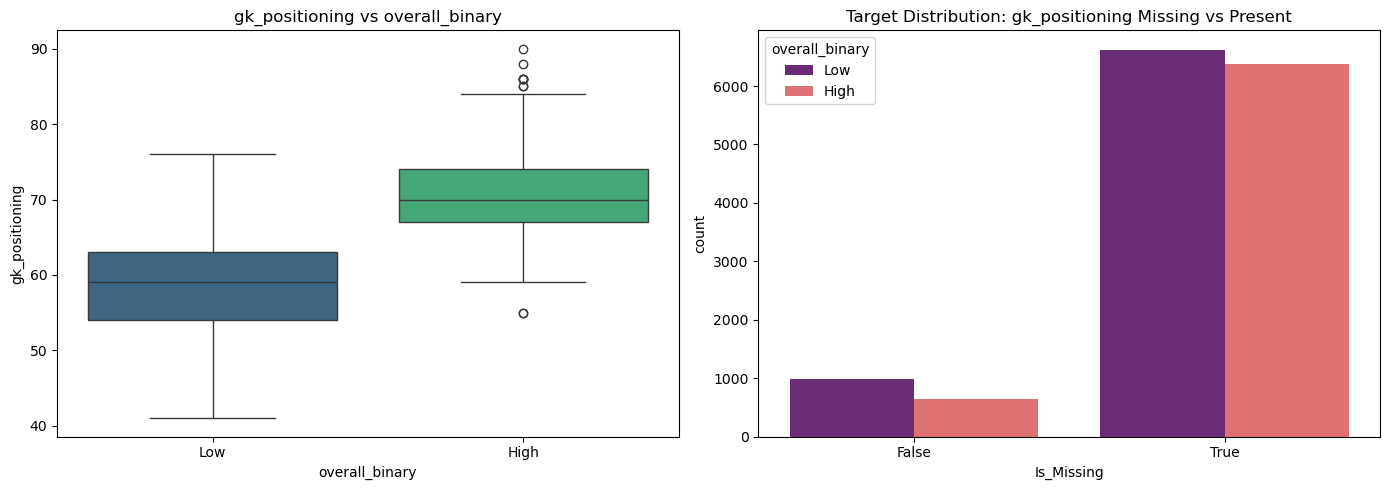

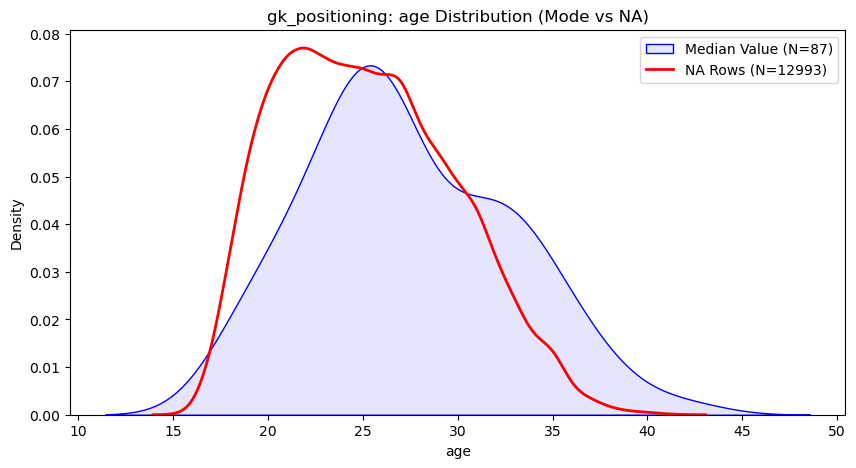

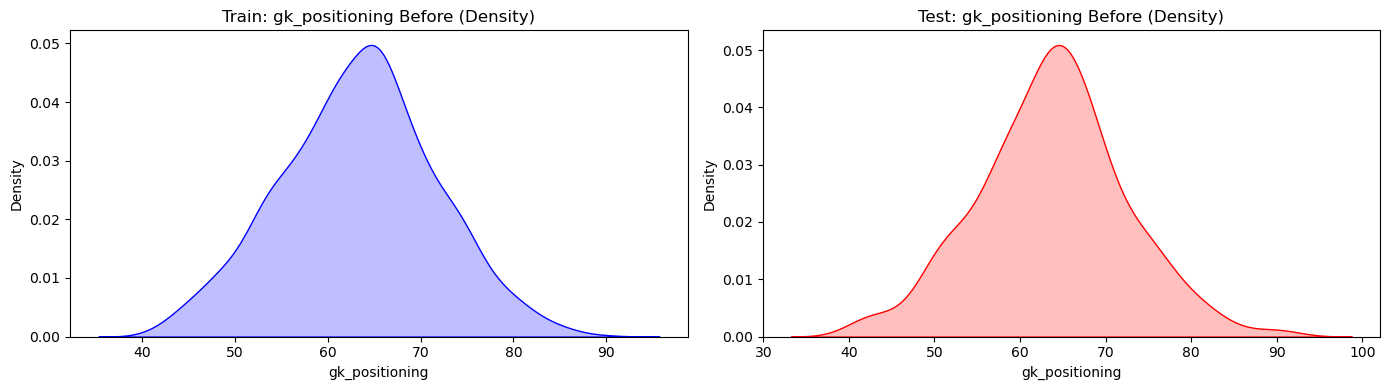

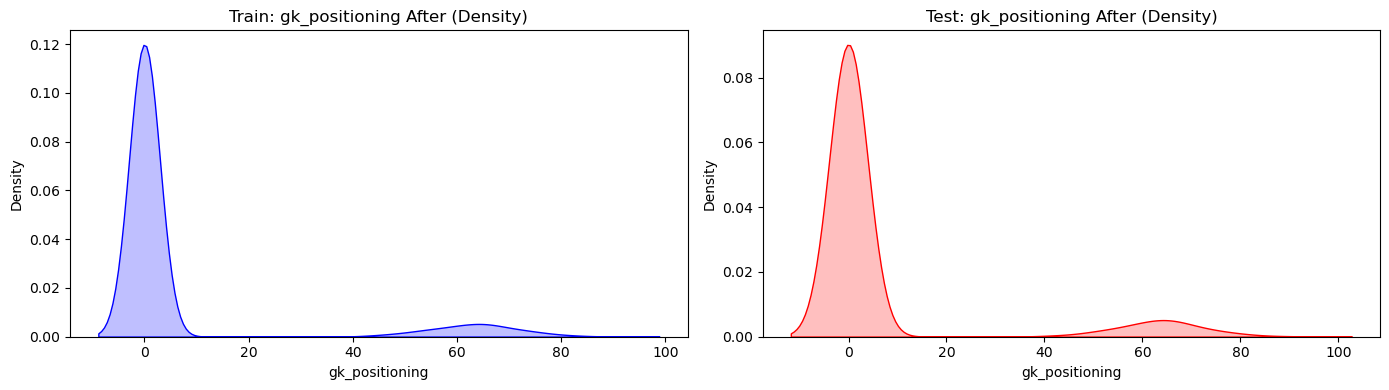

In [29]:
features_to_process = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 
                       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning']


plot_types = {
    'pace': 'dist',
    'shooting': 'dist',
    'passing': 'box',
    'dribbling': 'dist',
    'defending': 'box',
    'physic': 'dist',
    'gk_diving': 'box',
    'gk_handling': 'dist',
    'gk_kicking': 'box',
    'gk_reflexes': 'dist',
    'gk_speed': 'box',
    'gk_positioning': 'dist'
}

for feature in features_to_process:
   
    plot_type = plot_types.get(feature, 'dist')
    
    plot_analysis_vs_target(train_df, feature, target)
    # 2. Mode vs NA
    plot_mode_vs_na(train_df, feature)
    plot_feature_comparison(train_df, test_df, feature, stage="Before", plot_type=plot_type)
    
    train_df, test_df = impute_numerical(train_df, test_df, feature, method='constant')
    
    plot_feature_comparison(train_df, test_df, feature, stage="After", plot_type=plot_type)

✓ player_traits completed
✓ player_tags completed


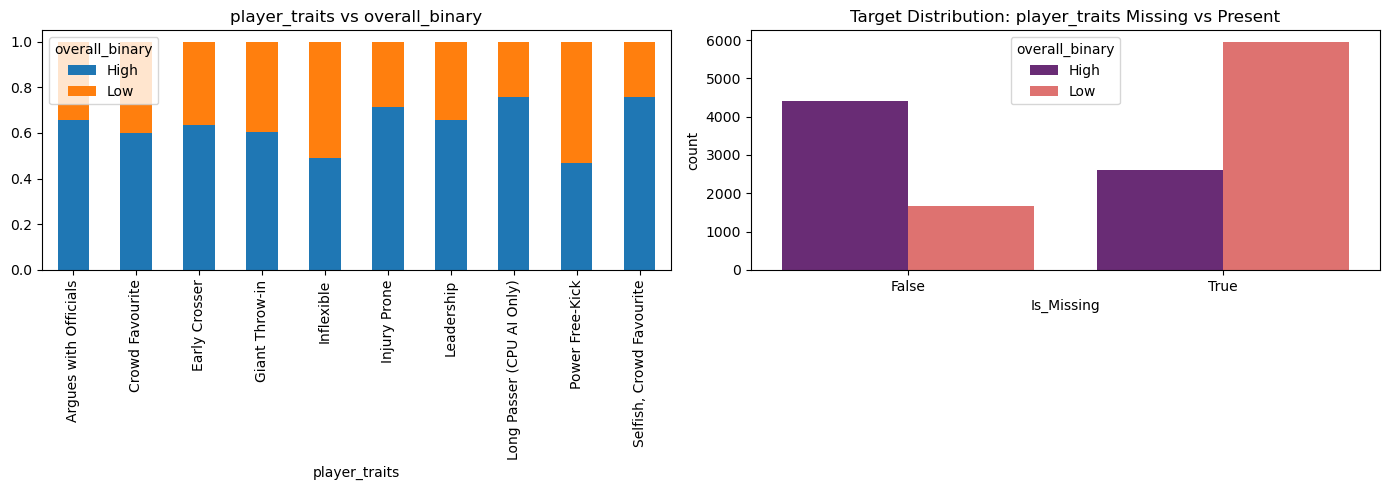

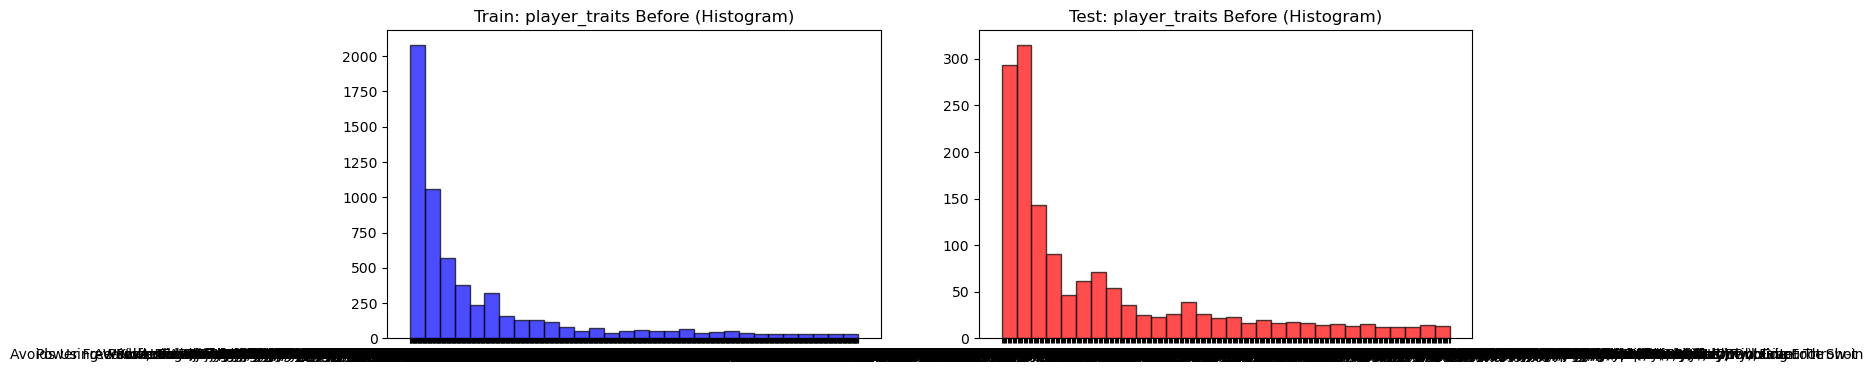

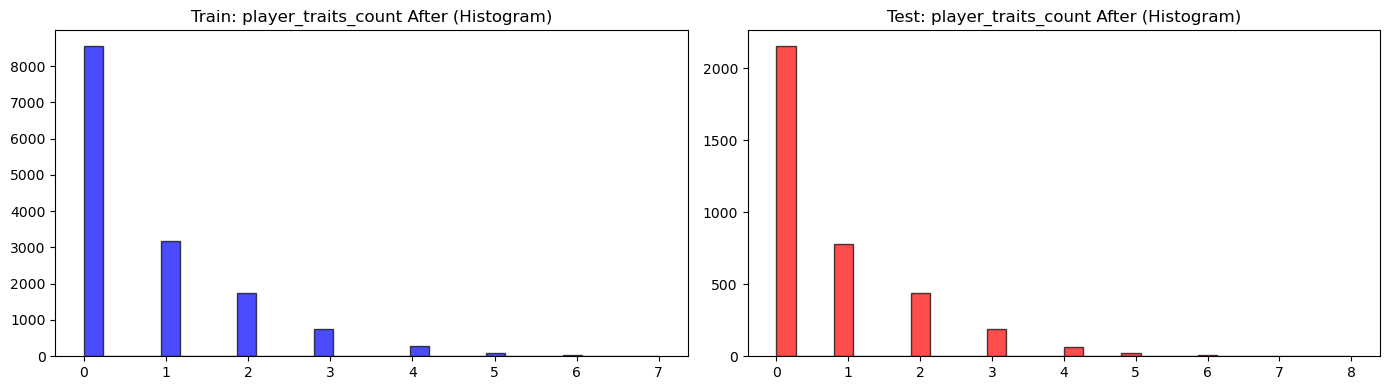

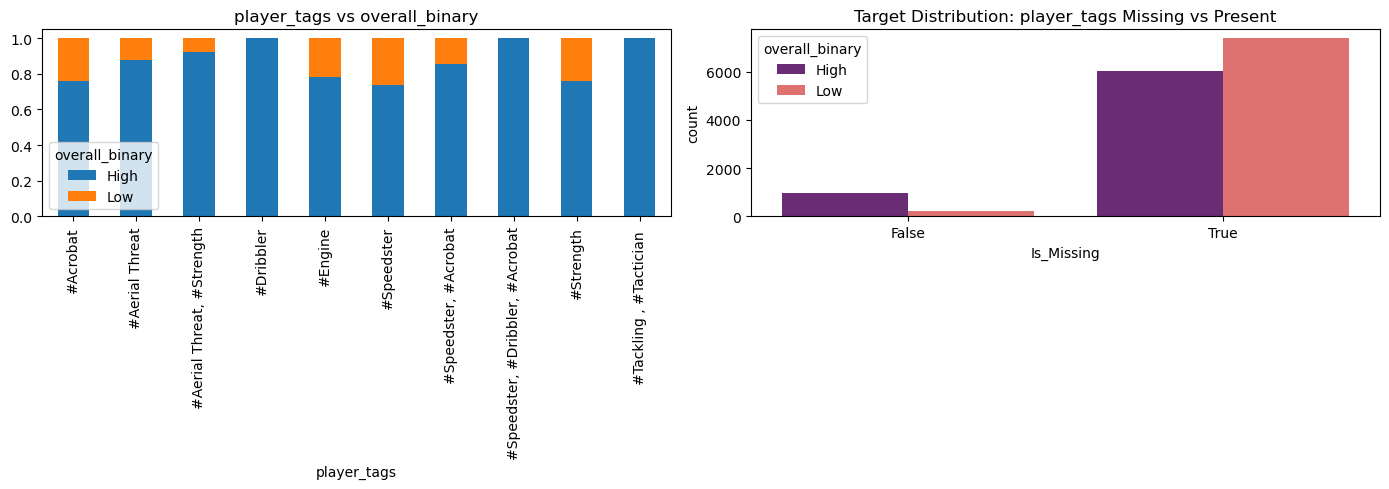

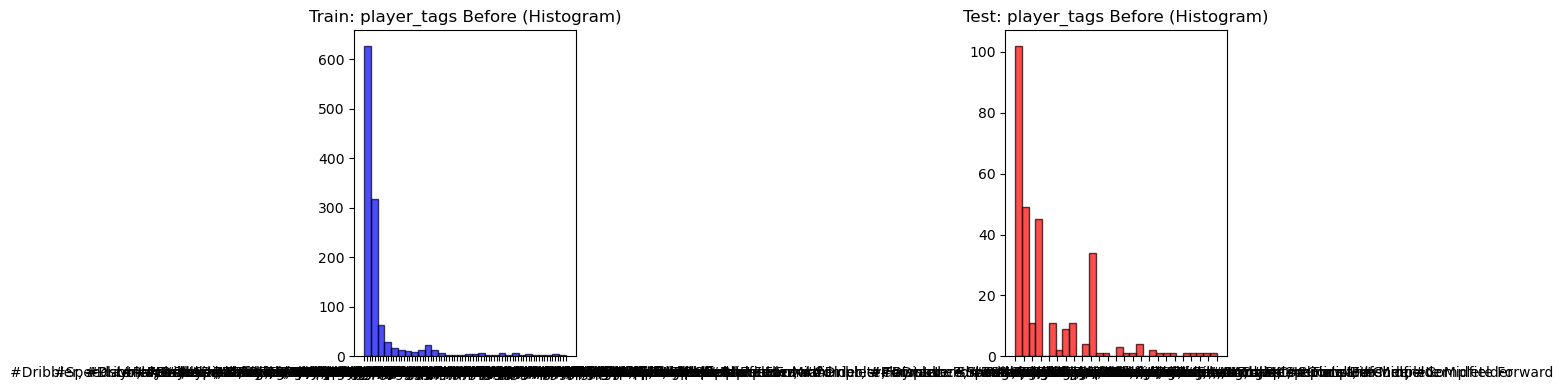

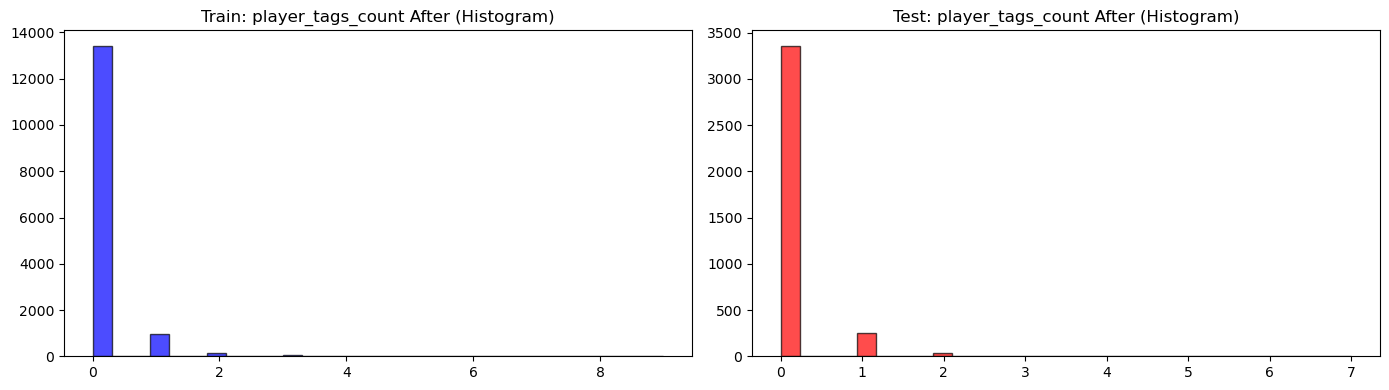

In [30]:

features_to_check = ['player_traits', 'player_tags', 'player_trait', 'player_tag', 'traits', 'tags']

for feature in features_to_check:
    
    if feature in train_df.columns and feature in test_df.columns:
        plot_analysis_vs_target(train_df, feature, target)
        plot_feature_comparison(train_df, test_df, feature, stage="Before", plot_type="hist")
        
        # Impute constant "None"
        train_df, test_df = impute_categorical(train_df, test_df, feature, method='constant')
        
        # Feature Engineering - create count column
        train_df[f'{feature}_count'] = train_df[feature].apply(lambda x: 0 if x == 'None' else len(x.split(',')))
        test_df[f'{feature}_count'] = test_df[feature].apply(lambda x: 0 if x == 'None' else len(x.split(',')))
        plot_feature_comparison(train_df, test_df, f'{feature}_count', stage="After", plot_type="hist")
        
        train_df.drop(columns=[feature], inplace=True)
        test_df.drop(columns=[feature], inplace=True)
        
        print(f"✓ {feature} completed")

In [31]:
num_cols = train_df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if train_df[col].isnull().any():
        train_df, test_df = impute_numerical(train_df, test_df, col, method='median')
# Categorical
cat_cols = train_df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if col != target and train_df[col].isnull().any():
        train_df, test_df = impute_categorical(train_df, test_df, col, method='constant')

# Identify unique values to encode

In [32]:
import pandas as pd

df = pd.read_csv('FIFA2020_dataset.csv')

pos_cols = ['ls', 'st', 'rs', 'lw', 'lf', 'cf', 'rf', 'rw', 'lam', 'cam', 'ram', 
            'lm', 'lcm', 'cm', 'rcm', 'rm', 'lwb', 'ldm', 'cdm', 'rdm', 'rwb', 
            'lb', 'lcb', 'cb', 'rcb', 'rb']

cat_cols = [c for c in df.select_dtypes(include=['object']).columns if c not in pos_cols]

groups = {
    "BINARY (2)": [],
    "LOW (3-15)": [],
    "MEDIUM (16-100)": [],
    "HIGH (>100)": []
}

for col in cat_cols:
    count = df[col].nunique()
    
    if count == 2:
        groups["BINARY (2)"].append((col, count))
    elif count <= 15:
        groups["LOW (3-15)"].append((col, count))
    elif count <= 100:
        groups["MEDIUM (16-100)"].append((col, count))
    else:
        groups["HIGH (>100)"].append((col, count))

for group_name, columns in groups.items():
    print(f"\n--- {group_name} ---")
    if not columns:
        print("None")
    for col, count in columns:
        print(f"{col}: {count}")


--- BINARY (2) ---
preferred_foot: 2
real_face: 2

--- LOW (3-15) ---
work_rate: 9
body_type: 10

--- MEDIUM (16-100) ---
player_tags: 83
team_position: 29
nation_position: 26

--- HIGH (>100) ---
player_url: 18278
short_name: 17354
long_name: 18218
dob: 6142
nationality: 162
club: 698
player_positions: 643
loaned_from: 316
joined: 1760
player_traits: 921


# Encoding

In [33]:
if 'joined' in train_df.columns:
    for df_temp in [train_df, test_df]:
        df_temp['joined'] = pd.to_datetime(df_temp['joined'], errors='coerce')
        df_temp['joined_year'] = df_temp['joined'].dt.year.fillna(0).astype(int)
        df_temp['joined_month'] = df_temp['joined'].dt.month.fillna(0).astype(int)
        df_temp.drop(columns=['joined'], inplace=True)

In [34]:
le_target = LabelEncoder()
train_df[target] = le_target.fit_transform(train_df[target].astype(str))
test_df[target] = le_target.transform(test_df[target].astype(str))

In [35]:
encoding_strategies = {
    'nationality': 'target', 'club': 'target', 'loaned_from': 'target',
    'player_positions': 'target', 'body_type': 'frequency',
    'team_position': 'frequency', 'nation_position': 'frequency',
    'work_rate': 'frequency', 'preferred_foot': 'one_hot', 'real_face': 'one_hot'
}

for col, method in encoding_strategies.items():
    if col not in train_df.columns: 
        continue
    
    if method == 'target':
        target_map = train_df.groupby(col)[target].mean()
        train_df[col] = train_df[col].map(target_map)
        test_df[col] = test_df[col].map(target_map).fillna(train_df[target].mean())
    
    elif method == 'frequency':
        freq_map = train_df[col].value_counts(normalize=True)
        train_df[col] = train_df[col].map(freq_map)
        test_df[col] = test_df[col].map(freq_map).fillna(0)
    
    elif method == 'one_hot':
        train_df = apply_one_hot_encoding(train_df, col, drop_first=True)
        test_df = apply_one_hot_encoding(test_df, col, drop_first=True)

In [36]:
remaining_objects = train_df.select_dtypes(include=['object']).columns.tolist()
print(f"Remaining object columns: {remaining_objects}")
print(f"Count: {len(remaining_objects)}")

Remaining object columns: []
Count: 0


In [37]:
print("Encoded train_df info:")
print(f"Shape: {train_df.shape}")
print(f"Object columns in train_df: {train_df.select_dtypes(include=['object']).columns.tolist()}")
print(f"All numeric: {len(train_df.select_dtypes(include=['object']).columns) == 0}")

print("\nFirst 5 rows of encoded train_df:")
print(train_df.head())

Encoded train_df info:
Shape: (14622, 78)
Object columns in train_df: []
All numeric: True

First 5 rows of encoded train_df:
       age  height_cm  weight_kg  nationality      club  overall  potential  \
13495   22        190         80     0.405660  0.130435       62         69   
542     29        188         84     0.333333  0.200000       80         80   
10157   22        174         60     0.690840  0.619048       65         73   
11221   22        185         72     0.703927  0.214286       64         74   
1071    24        188         76     0.246032  0.227273       77         81   

       wage_eur  player_positions  international_reputation  ...  \
13495      3000          0.609576                         1  ...   
542       90000          0.486200                         2  ...   
10157      2000          0.648936                         1  ...   
11221      6000          0.486200                         1  ...   
1071      16000          0.315789                         2

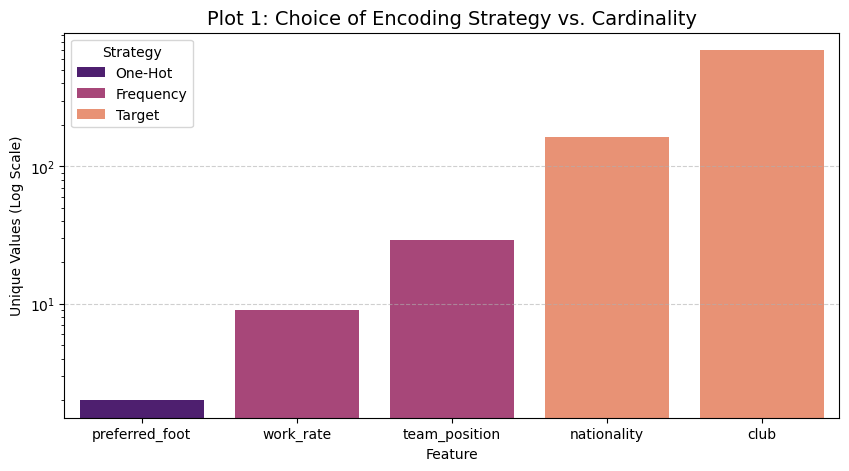

In [38]:
features = ['preferred_foot', 'work_rate', 'team_position', 'nationality', 'club']
counts = [2, 9, 29, 162, 698]
strats = ['One-Hot', 'Frequency', 'Frequency', 'Target', 'Target']
card_df = pd.DataFrame({'Feature': features, 'Unique_Values': counts, 'Strategy': strats})

plt.figure(figsize=(10, 5))
sns.barplot(data=card_df, x='Feature', y='Unique_Values', hue='Strategy', palette='magma')
plt.yscale('log')
plt.title('Plot 1: Choice of Encoding Strategy vs. Cardinality', fontsize=14)
plt.ylabel('Unique Values (Log Scale)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig('encoding_justification.png')

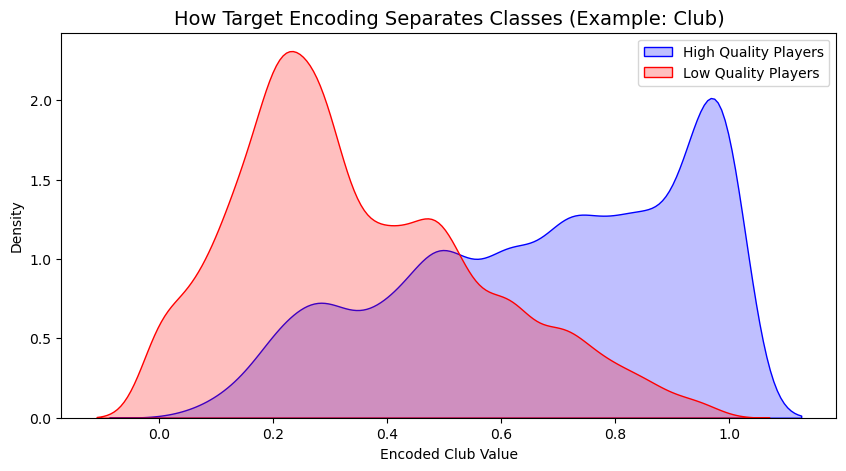

In [39]:

dataframe_to_plot = train_df  
target_column = 'overall_binary' 

plt.figure(figsize=(10, 5))
sns.kdeplot(
    dataframe_to_plot[dataframe_to_plot[target_column] == 1]['club'], 
    label='High Quality Players', 
    fill=True, 
    color='blue'
)

sns.kdeplot(
    dataframe_to_plot[dataframe_to_plot[target_column] == 0]['club'], 
    label='Low Quality Players', 
    fill=True, 
    color='red'
)
plt.title('How Target Encoding Separates Classes (Example: Club)', fontsize=14)
plt.xlabel('Encoded Club Value')
plt.ylabel('Density')
plt.legend()
plt.show()

In [40]:
print("Checking for missing values after encoding:")
missing_train = train_df.isnull().sum().sum()
missing_test = test_df.isnull().sum().sum()
print(f"Train missing: {missing_train}")
print(f"Test missing: {missing_test}")

train_missing_cols = train_df.columns[train_df.isnull().any()].tolist()
test_missing_cols = test_df.columns[test_df.isnull().any()].tolist()
print(f"\nColumns with missing in train: {train_missing_cols}")
print(f"Columns with missing in test: {test_missing_cols}")

Checking for missing values after encoding:
Train missing: 0
Test missing: 0

Columns with missing in train: []
Columns with missing in test: []


# Scaling and corrolation of processed data


STAGE 2: Correlation Heatmap - Processed & Scaled Data


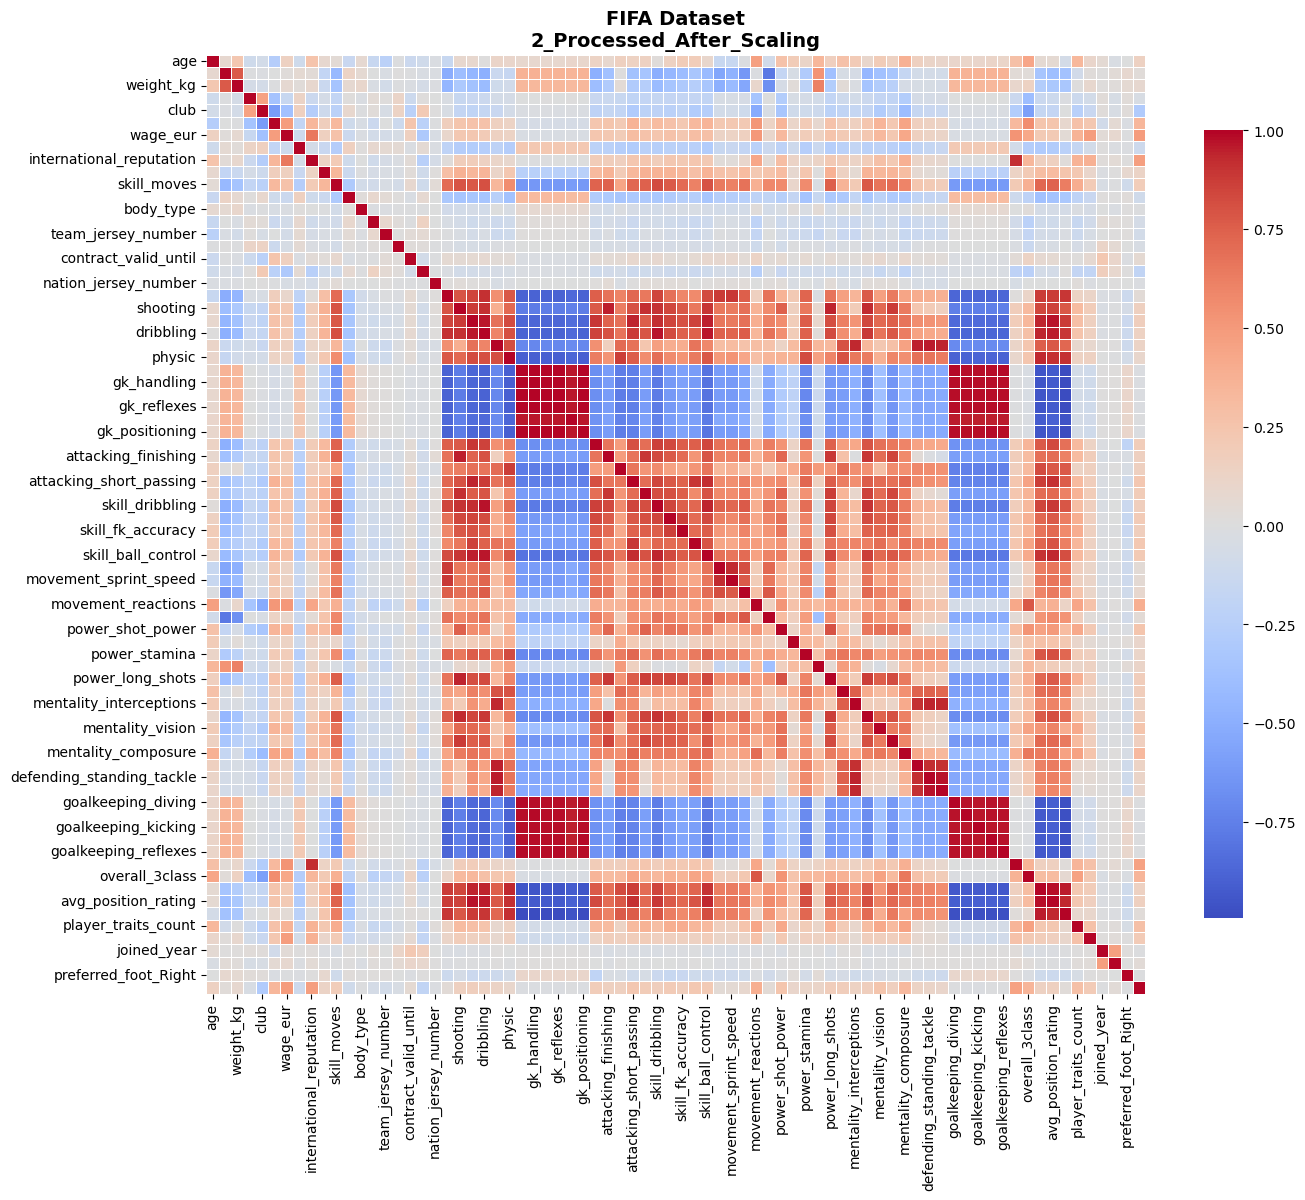


⚠️ HIGH CORRELATIONS > 0.9 at 2_Processed_After_Scaling:
  gk_diving                 ↔ gk_reflexes              : 0.9986
  gk_handling               ↔ gk_positioning           : 0.9977
  gk_diving                 ↔ gk_handling              : 0.9976
  gk_diving                 ↔ gk_positioning           : 0.9973
  gk_reflexes               ↔ gk_positioning           : 0.9972
  gk_handling               ↔ gk_reflexes              : 0.9972
  gk_handling               ↔ gk_kicking               : 0.9960
  gk_diving                 ↔ gk_kicking               : 0.9958
  gk_kicking                ↔ gk_reflexes              : 0.9954
  gk_kicking                ↔ gk_positioning           : 0.9953
  gk_handling               ↔ num_positions            : -0.9927
  gk_diving                 ↔ num_positions            : -0.9922
  gk_kicking                ↔ num_positions            : -0.9919
  gk_reflexes               ↔ num_positions            : -0.9915
  gk_positioning            ↔ num_position

In [52]:
cols_to_drop = ['overall', target] 

X_train = train_df.drop(columns=cols_to_drop, errors='ignore')
X_test = test_df.drop(columns=cols_to_drop, errors='ignore')


numeric_columns = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()


assert target not in X_train.columns, "Target column found in features before scaling"
assert target not in X_test.columns, "Target column found in features before scaling"

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_columns] = pd.DataFrame(
    scaler.fit_transform(X_train[numeric_columns]), 
    columns=numeric_columns,
    index=X_train.index
)
X_test_scaled[numeric_columns] = pd.DataFrame(
    scaler.transform(X_test[numeric_columns]), 
    columns=numeric_columns,
    index=X_test.index
)

# ========== STAGE 2 CORRELATION HEATMAP ==========
X_train_scaled[target] = train_df[target].values

print("\n" + "="*60)
print("STAGE 2: Correlation Heatmap - Processed & Scaled Data")
print("="*60)
plot_correlation_heatmap(X_train_scaled.drop(columns=[target]),  
                        "FIFA Dataset", 
                        "2_Processed_After_Scaling",
                        threshold=0.9, triangle=False)

# ========== CONTINUE WITH SAVING ==========
X_train_scaled.to_csv('FIFA_Binary_Cleaned_Final_Train.csv', index=False)
X_test_scaled[target] = test_df[target].values  
X_test_scaled.to_csv('FIFA_Binary_Cleaned_Final_Test.csv', index=False)

print("✅ Preprocessing Complete!")
print(f"Train shape: {X_train_scaled.shape}")
print(f"Test shape: {X_test_scaled.shape}")
print(f"Target classes: {le_target.classes_}")